# Validating the Gaussian Well Energy Landscape in Transformer Hidden State Space

**Research question**: Could the STP loss be understood as an emergent property of an underlying Lagrangian with a Gaussian-well-type potential?

This notebook implements the experimental protocol described in  
`docs/STP_Loss_Is_An_Emergent_Property_Of_The_Energy_Landscape_Defined_By_Gaussian_Well_Potential.md`

## Experimental stages

| Stage | Goal |
|-------|------|
| 1 | Extract hidden states from a pre-trained transformer |
| 2 | Compute per-token NTP loss as a proxy for potential energy |
| 3 | Compute distance of each hidden state from the trajectory center |
| 4 | Fit Gaussian well, harmonic, and linear potentials; compare |
| 5 | Reconstruct the Lagrangian and compute total action; correlate with STP loss |

## 0. Setup

Install `torch` and `transformers` if not already present.  
Uncomment the appropriate pip line for your hardware.

In [1]:
# --- Uncomment ONE of the following lines to install PyTorch ---

# CPU-only (works everywhere)
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

# macOS with Apple Silicon (MPS backend)
# !pip install torch torchvision

# CUDA 12.x
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

# --- Then install transformers ---
# !pip install transformers accelerate

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm
from dataclasses import dataclass, field
from typing import Optional
import warnings
import json
import os

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available:  {torch.backends.mps.is_available()}")

PyTorch 2.2.2
CUDA available: False
MPS available:  True


## 1. Configuration

In [3]:
def _pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        try:
            torch.zeros(1, device="mps")
            return "mps"
        except Exception:
            pass
    return "cpu"


@dataclass
class Config:
    # ----- Model -----
    # Primary choice (Huang et al.'s model — requires HF auth token):
    #   model_name: str = "meta-llama/Llama-3.2-1B"
    # Pipeline-testing fallback (no auth, 124M params):
    model_name: str = "gpt2"

    # ----- Hardware -----
    device: str = field(default_factory=_pick_device)
    dtype: torch.dtype = field(default_factory=lambda: (
        torch.float16 if torch.cuda.is_available() else torch.float32
    ))

    # ----- Extraction -----
    max_length: int = 256
    hidden_layer: int = -1            # which layer to probe (-1 = last)

    # ----- STP sampling -----
    num_stp_triplets: int = 500       # random triplets per trajectory

    # ----- Output -----
    output_dir: str = "results"


cfg = Config()

if os.path.isdir("notebooks/stp_loss"):
    cfg.output_dir = "notebooks/stp_loss/results"

os.makedirs(cfg.output_dir, exist_ok=True)
print(f"Model : {cfg.model_name}")
print(f"Device: {cfg.device}  dtype: {cfg.dtype}")

Model : gpt2
Device: mps  dtype: torch.float32


---
## Stage 1 — Hidden State Extraction

### 1.1 Load model and tokenizer

In [4]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    torch_dtype=cfg.dtype,
).to(cfg.device)
model.eval()

vocab_size = model.config.vocab_size
hidden_dim = model.config.hidden_size
num_layers = model.config.num_hidden_layers
print(f"Loaded {cfg.model_name}")
print(f"  vocab_size  = {vocab_size}")
print(f"  hidden_dim  = {hidden_dim}")
print(f"  num_layers  = {num_layers}")
print(f"  parameters  = {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded gpt2
  vocab_size  = 50257
  hidden_dim  = 768
  num_layers  = 12
  parameters  = 124.4M


### 1.2 Curated sentence corpus

Sentences span five semantic domains so we can later test whether
the fitted well parameters ($\mathfrak{m}$, $\upsilon$, $\kappa$) vary across domains
(Prediction 5 in the research document).

In [5]:
CORPUS = {
    "mathematics": [
        "The fundamental theorem of calculus establishes that differentiation and integration are inverse operations of each other.",
        "A metric space is a set together with a notion of distance between its elements, usually called points, that satisfies a set of axioms.",
        "Euler's identity connects the five most important numbers in mathematics through the equation e to the power of i pi plus one equals zero.",
        "The eigenvalues of a symmetric matrix are always real, and the eigenvectors corresponding to distinct eigenvalues are orthogonal.",
        "Gödel's incompleteness theorems demonstrate that in any consistent formal system capable of expressing basic arithmetic there exist statements that can neither be proved nor disproved.",
        "The Riemann hypothesis conjectures that all non-trivial zeros of the Riemann zeta function have real part equal to one half.",
        "A group homomorphism preserves the algebraic structure by mapping the identity element to the identity element and products to products.",
        "The central limit theorem states that the sum of a large number of independent random variables tends toward a normal distribution regardless of the underlying distribution.",
        "Hilbert spaces generalize the notion of Euclidean space to infinite dimensions while retaining the structure of an inner product.",
        "The Lagrangian of a mechanical system equals the kinetic energy minus the potential energy and encodes the complete dynamics through the Euler-Lagrange equations.",
    ],
    "narrative": [
        "The old lighthouse keeper climbed the spiral staircase one last time, his weathered hands gripping the iron railing as the storm gathered outside.",
        "She found the letter tucked between the pages of a book she hadn't opened in years, the ink faded but the words still sharp enough to wound.",
        "The train pulled into the empty station at midnight, its headlamp cutting through the fog like a single unblinking eye.",
        "He sat on the porch watching the fireflies trace their erratic paths through the warm summer air while the radio played something slow and sad.",
        "The market was closing for the day and the vendors were packing up their unsold fruit, bruised peaches and overripe plums going back into crates.",
        "She ran through the forest with branches whipping at her face, the sound of the river growing louder with every desperate step.",
        "The children built a fort out of couch cushions and draped a bedsheet over the top, declaring it a castle that no adults could enter.",
        "He returned to the village after twenty years and found that the oak tree in the square had been cut down and replaced by a parking lot.",
        "The ship appeared on the horizon at dawn, its sails torn and its hull battered, carrying survivors of a voyage no one had expected to end.",
        "She opened the door to find the apartment exactly as she had left it, dust settled on every surface like a thin layer of forgotten time.",
    ],
    "scientific": [
        "Photosynthesis converts carbon dioxide and water into glucose and oxygen using light energy captured by chlorophyll molecules in the thylakoid membranes.",
        "The double helix structure of DNA consists of two antiparallel strands held together by hydrogen bonds between complementary base pairs adenine-thymine and guanine-cytosine.",
        "General relativity describes gravity not as a force but as the curvature of spacetime caused by the presence of mass and energy.",
        "Neurons communicate across synaptic clefts by releasing neurotransmitters that bind to receptors on the postsynaptic membrane and trigger ion channel opening.",
        "The cosmic microwave background radiation is the thermal remnant of the early universe, emitted approximately 380,000 years after the Big Bang when atoms first formed.",
        "Plate tectonics explains the movement of lithospheric plates driven by convection currents in the asthenosphere, producing earthquakes, volcanoes, and mountain ranges.",
        "Quantum entanglement describes a correlation between particles such that measuring the state of one instantaneously determines the state of the other regardless of distance.",
        "The mitochondrial electron transport chain transfers electrons through a series of protein complexes to generate a proton gradient that drives ATP synthesis.",
        "Black holes form when massive stars exhaust their nuclear fuel and collapse under their own gravity, creating a singularity surrounded by an event horizon.",
        "CRISPR-Cas9 is a genome editing tool that uses a guide RNA to direct the Cas9 nuclease to a specific DNA sequence where it makes a double-strand break.",
    ],
    "code_description": [
        "The function iterates over the input list, applies a filter predicate to each element, and collects the matching elements into a new list that is returned.",
        "A binary search tree maintains the invariant that for every node, all values in the left subtree are smaller and all values in the right subtree are larger.",
        "The garbage collector identifies unreachable objects by tracing references from root pointers and reclaims their memory for future allocations.",
        "Dependency injection decouples object creation from usage by passing required services through constructor parameters rather than instantiating them internally.",
        "The load balancer distributes incoming HTTP requests across a pool of backend servers using a round-robin algorithm with health check probes every thirty seconds.",
        "A database transaction groups multiple operations into an atomic unit that either commits all changes or rolls back entirely if any operation fails.",
        "The recursive function computes the Fibonacci sequence by returning the sum of the two preceding values with base cases returning zero and one respectively.",
        "Hash maps achieve average constant time lookups by computing a hash of the key and using it as an index into an array of buckets.",
        "The event loop processes asynchronous callbacks from a message queue, executing each callback to completion before moving to the next one in the queue.",
        "Backpropagation computes gradients of the loss function with respect to each weight by applying the chain rule layer by layer from the output to the input.",
    ],
    "conversational": [
        "I was thinking we could grab dinner at that new place on Fifth Street, the one with the rooftop patio, if you're not too tired after work.",
        "Did you see the game last night? I couldn't believe they came back from a twenty-point deficit in the fourth quarter to win by three.",
        "My neighbor's dog got out again this morning and I spent half an hour chasing it around the block before finally catching it near the park.",
        "I've been meaning to tell you that the meeting got moved to Thursday, so we have an extra day to finish the presentation slides.",
        "The traffic was absolutely terrible this morning, it took me almost two hours to get to the office when it usually takes thirty minutes.",
        "Do you remember that restaurant we went to on vacation last summer? I found out they just opened a second location near downtown.",
        "I'm trying to decide between the blue one and the red one but honestly they both look great so maybe I should just get both.",
        "She told me she's thinking about going back to school to study architecture, which is funny because she used to say she'd never set foot in a classroom again.",
        "Can you pick up some milk on the way home? We also need bread and I think we're almost out of coffee too.",
        "I finally finished that book you recommended and you were right, the ending was completely unexpected but somehow felt inevitable in retrospect.",
    ],
}

all_sentences = []
all_domains = []
for domain, sents in CORPUS.items():
    for s in sents:
        all_sentences.append(s)
        all_domains.append(domain)

print(f"Corpus: {len(all_sentences)} sentences across {len(CORPUS)} domains")
for d, sents in CORPUS.items():
    print(f"  {d:20s}: {len(sents)} sentences")

Corpus: 50 sentences across 5 domains
  mathematics         : 10 sentences
  narrative           : 10 sentences
  scientific          : 10 sentences
  code_description    : 10 sentences
  conversational      : 10 sentences


### 1.3 Hidden state and logit extraction

For each sentence we extract:
- Last-layer hidden states $h_t \in \mathbb{R}^d$ at every token position
- Logits for next-token prediction at every position
- The token ids (for computing the NTP loss target)

In [6]:
@dataclass
class Trajectory:
    """All quantities extracted from a single sentence."""
    sentence: str
    domain: str
    token_ids: np.ndarray          # (T,)
    hidden_states: np.ndarray      # (T, d)
    per_token_loss: np.ndarray     # (T-1,)  — energy proxy V(h_t)
    distances: Optional[np.ndarray] = None      # (T-1,)
    center: Optional[np.ndarray] = None         # (d,)


def extract_trajectory(sentence: str, domain: str) -> Trajectory:
    """Run one sentence through the model; return hidden states and per-token loss."""
    enc = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=cfg.max_length,
    )
    input_ids = enc["input_ids"].to(cfg.device)

    with torch.no_grad():
        out = model(
            input_ids,
            output_hidden_states=True,
        )

    hs = out.hidden_states[cfg.hidden_layer][0].float().cpu().numpy()   # (T, d)
    logits = out.logits[0].float()                                      # (T, V)

    # Per-token cross-entropy loss (next-token prediction)
    shift_logits = logits[:-1]               # (T-1, V)
    shift_labels = input_ids[0, 1:]          # (T-1,)
    ptl = F.cross_entropy(
        shift_logits, shift_labels, reduction="none"
    ).cpu().numpy()                          # (T-1,)

    return Trajectory(
        sentence=sentence,
        domain=domain,
        token_ids=input_ids[0].cpu().numpy(),
        hidden_states=hs,
        per_token_loss=ptl,
    )

In [7]:
trajectories: list[Trajectory] = []
for sent, dom in tqdm(zip(all_sentences, all_domains), total=len(all_sentences), desc="Extracting"):
    trajectories.append(extract_trajectory(sent, dom))

T_lengths = [t.hidden_states.shape[0] for t in trajectories]
print(f"\nExtracted {len(trajectories)} trajectories")
print(f"  token lengths: min={min(T_lengths)}, max={max(T_lengths)}, mean={np.mean(T_lengths):.1f}")
print(f"  hidden dim:    {trajectories[0].hidden_states.shape[1]}")

Extracting:   0%|          | 0/50 [00:00<?, ?it/s]


Extracted 50 trajectories
  token lengths: min=17, max=39, mean=28.3
  hidden dim:    768


---
## Stage 2 — Energy Proxy (Per-Token NTP Loss)

The cross-entropy loss $\mathcal{L}_{NTP}(h_t)$ at each token position serves as a
proxy for the potential energy $V(h_t)$.  High loss = the model is "far" from
the correct prediction = high potential energy.

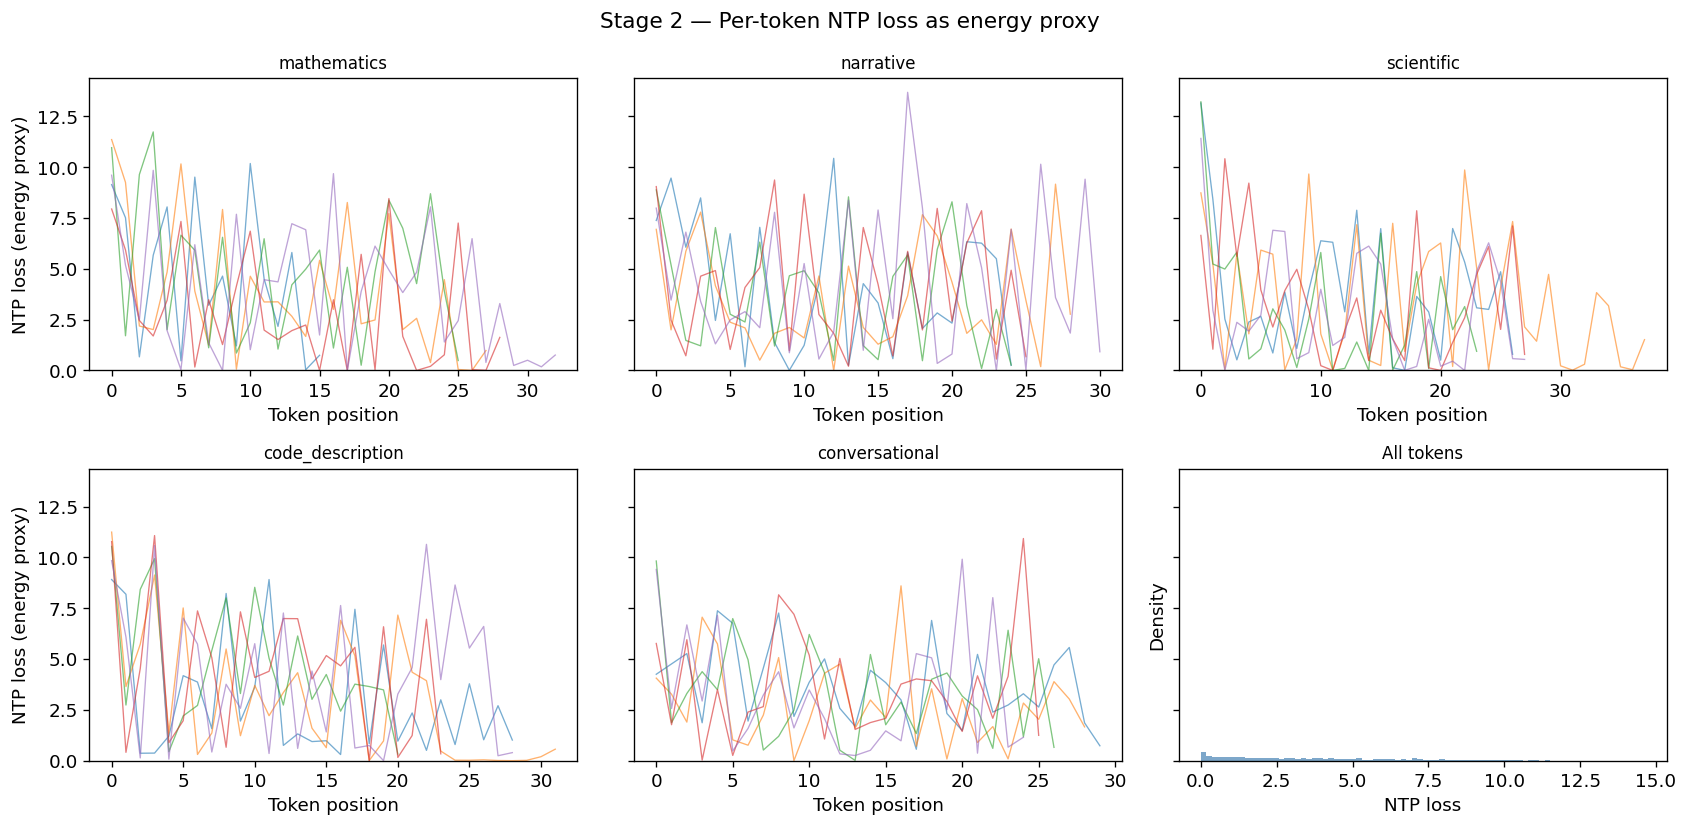

Energy proxy stats across all tokens:
  mean = 3.6693
  std  = 2.9714
  min  = 0.0001
  max  = 14.6219


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
axes = axes.ravel()

for i, dom in enumerate(CORPUS.keys()):
    ax = axes[i]
    dom_trajs = [t for t in trajectories if t.domain == dom]
    for t in dom_trajs[:5]:
        ax.plot(t.per_token_loss, alpha=0.6, linewidth=0.8)
    ax.set_title(dom, fontsize=10)
    ax.set_xlabel("Token position")
    if i % 3 == 0:
        ax.set_ylabel("NTP loss (energy proxy)")

# Aggregate distribution
ax = axes[5]
all_losses = np.concatenate([t.per_token_loss for t in trajectories])
ax.hist(all_losses, bins=80, density=True, alpha=0.7, color="steelblue")
ax.set_title("All tokens", fontsize=10)
ax.set_xlabel("NTP loss")
ax.set_ylabel("Density")

fig.suptitle("Stage 2 — Per-token NTP loss as energy proxy", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage2_energy_proxy.png"), dpi=150)
plt.show()

print(f"Energy proxy stats across all tokens:")
print(f"  mean = {all_losses.mean():.4f}")
print(f"  std  = {all_losses.std():.4f}")
print(f"  min  = {all_losses.min():.4f}")
print(f"  max  = {all_losses.max():.4f}")

---
## Stage 3 — Cosine Distance from Trajectory Center

For each trajectory we compute:
1. The **center** — the final hidden state $h_T$ is used as the default, as it
   best approximates the bound state (semantic target) of the trajectory.
   The arithmetic mean $\bar{h}$ is available as a fallback.
2. The **cosine distance** $d_{\cos}(h_t, c) = 1 - \cos(h_t, c)$ of each hidden
   state from the center. Cosine distance is preferred over Euclidean because:
   - It matches the metric used by the STP loss itself
   - It is immune to the concentration-of-measure effect in high dimensions
   - It measures angular separation, which is how transformers encode semantic similarity

In [9]:
def cosine_distance(a, b):
    """Cosine distance: 1 - cos(a, b).  a: (N, d), b: (d,) -> (N,)."""
    dot = np.sum(a * b[None, :], axis=1)
    norm_a = np.linalg.norm(a, axis=1)
    norm_b = np.linalg.norm(b) + 1e-12
    return 1.0 - dot / (norm_a * norm_b + 1e-12)


def compute_distances(traj: Trajectory, use_final_state: bool = True) -> Trajectory:
    """Compute cosine distance of each hidden state from the trajectory center.

    Uses hidden states h_1 ... h_{T-1} (aligned with per_token_loss indices).
    Center is the final hidden state h_T (bound-state proxy) by default,
    or the arithmetic mean of the trajectory.
    """
    hs = traj.hidden_states[:-1]     # (T-1, d) — aligned with per_token_loss

    if use_final_state:
        center = traj.hidden_states[-1]
    else:
        center = hs.mean(axis=0)

    dists = cosine_distance(hs, center)
    traj.center = center
    traj.distances = dists
    return traj


for traj in trajectories:
    compute_distances(traj, use_final_state=True)

all_dists = np.concatenate([t.distances for t in trajectories])
print(f"Cosine distance stats (center = final hidden state):")
print(f"  mean = {all_dists.mean():.6f}")
print(f"  std  = {all_dists.std():.6f}")
print(f"  min  = {all_dists.min():.6f}")
print(f"  max  = {all_dists.max():.6f}")

Cosine distance stats (center = final hidden state):
  mean = 0.024474
  std  = 0.024505
  min  = 0.000665
  max  = 0.442161


---
## Stage 4 — Gaussian Well Fitting

We fit three potential models to the (cosine distance, energy) data:

| Model | Formula | Free parameters |
|-------|---------|-----------------| 
| Gaussian well | $V(x) = a\left(1 - e^{-b x^2}\right)$ | $a, b$ |
| Harmonic | $V(x) = c \cdot x^2$ | $c$ |
| Linear | $V(x) = d \cdot x$ | $d$ |

where $x = 1 - \cos(h_t, c)$ is the cosine distance from the trajectory center.
The Gaussian well corresponds to $a = \mathfrak{m}\upsilon^2$ and $b = \kappa^2$.

In [10]:
# ---- Potential models ----

def gaussian_well(x, a, b):
    return a * (1.0 - np.exp(-b * x**2))

def harmonic(x, c):
    return c * x**2

def linear_pot(x, d):
    return d * x


def fit_potentials(distances, energies):
    """Fit all three potentials. Returns dict of {name: (popt, residuals, r_squared, aic)}."""
    results = {}
    n = len(distances)

    for name, func, p0, k in [
        ("gaussian_well", gaussian_well, [energies.max(), 1.0 / (distances.std()**2 + 1e-8)], 2),
        ("harmonic",      harmonic,      [energies.mean() / (distances.mean()**2 + 1e-8)], 1),
        ("linear",        linear_pot,    [energies.mean() / (distances.mean() + 1e-8)], 1),
    ]:
        try:
            popt, _ = curve_fit(func, distances, energies, p0=p0, maxfev=20000)
            predicted = func(distances, *popt)
            ss_res = np.sum((energies - predicted) ** 2)
            ss_tot = np.sum((energies - energies.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-12)
            aic = n * np.log(ss_res / n + 1e-12) + 2 * k
            results[name] = {"popt": popt, "r2": r2, "aic": aic, "ss_res": ss_res}
        except RuntimeError:
            results[name] = {"popt": None, "r2": -np.inf, "aic": np.inf, "ss_res": np.inf}

    return results

### 4.1 Global fit (all trajectories pooled)

In [11]:
all_d = np.concatenate([t.distances for t in trajectories])
all_e = np.concatenate([t.per_token_loss for t in trajectories])

global_fits = fit_potentials(all_d, all_e)

print("Global fit results (all trajectories pooled):")
print(f"{'Model':<18} {'R²':>10} {'AIC':>12} {'Parameters'}")
print("-" * 65)
for name, res in global_fits.items():
    params = ", ".join(f"{v:.6f}" for v in res["popt"]) if res["popt"] is not None else "FAILED"
    print(f"{name:<18} {res['r2']:>10.6f} {res['aic']:>12.2f} [{params}]")

best = min(global_fits, key=lambda k: global_fits[k]["aic"])
print(f"\n→ Best model by AIC: {best}")

Global fit results (all trajectories pooled):
Model                      R²          AIC Parameters
-----------------------------------------------------------------
gaussian_well        0.000000      2974.86 [3.669321, 39425833.244444]
harmonic            -1.516422      4231.61 [31.939265]
linear              -0.913948      3858.33 [67.063992]

→ Best model by AIC: gaussian_well


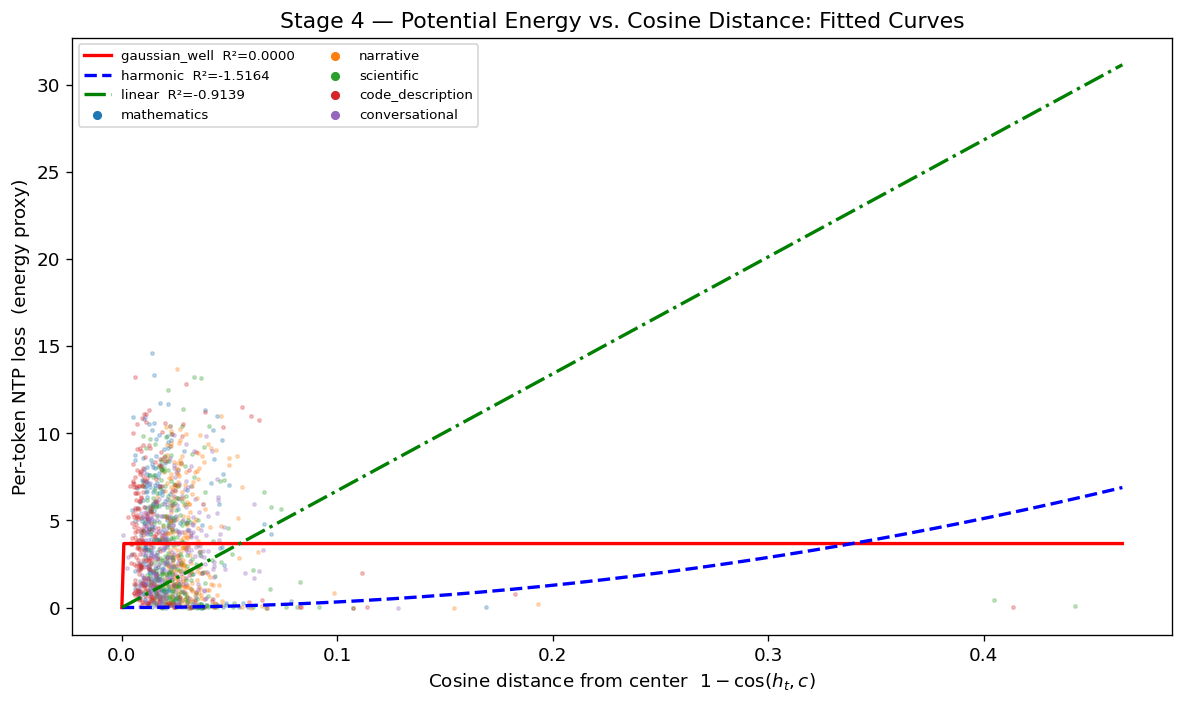

In [12]:
# ---- Scatter plot with fitted curves ----

fig, ax = plt.subplots(figsize=(10, 6))

domain_colors = {d: c for d, c in zip(CORPUS.keys(), plt.cm.tab10.colors)}
for traj in trajectories:
    ax.scatter(
        traj.distances, traj.per_token_loss,
        c=[domain_colors[traj.domain]], s=4, alpha=0.25,
    )

x_fit = np.linspace(0, all_d.max() * 1.05, 500)
styles = {"gaussian_well": ("red", "-"), "harmonic": ("blue", "--"), "linear": ("green", "-.")}
for name, res in global_fits.items():
    if res["popt"] is None:
        continue
    func = {"gaussian_well": gaussian_well, "harmonic": harmonic, "linear": linear_pot}[name]
    color, ls = styles[name]
    ax.plot(x_fit, func(x_fit, *res["popt"]), color=color, ls=ls, lw=2,
            label=f"{name}  R²={res['r2']:.4f}")

# Legend for domains
for dom, col in domain_colors.items():
    ax.scatter([], [], c=[col], s=20, label=dom)

ax.set_xlabel("Cosine distance from center  $1 - \\cos(h_t, c)$")
ax.set_ylabel("Per-token NTP loss  (energy proxy)")
ax.set_title("Stage 4 — Potential Energy vs. Cosine Distance: Fitted Curves")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage4_global_fit.png"), dpi=150)
plt.show()

### 4.2 Per-domain fits

Test **Prediction 5**: do the fitted Gaussian well parameters differ systematically across semantic domains?

In [13]:
domain_fit_results = {}

for dom in CORPUS.keys():
    dom_trajs = [t for t in trajectories if t.domain == dom]
    d_arr = np.concatenate([t.distances for t in dom_trajs])
    e_arr = np.concatenate([t.per_token_loss for t in dom_trajs])
    domain_fit_results[dom] = fit_potentials(d_arr, e_arr)

print(f"{'Domain':<18} {'a (m·υ²)':>12} {'b (κ²)':>12} {'R² (Gauss)':>12} {'R² (Harm)':>12} {'R² (Lin)':>12}")
print("-" * 80)
for dom, fits in domain_fit_results.items():
    gw = fits["gaussian_well"]
    hr = fits["harmonic"]
    ln = fits["linear"]
    if gw["popt"] is not None:
        a, b = gw["popt"]
        print(f"{dom:<18} {a:>12.4f} {b:>12.6f} {gw['r2']:>12.6f} {hr['r2']:>12.6f} {ln['r2']:>12.6f}")
    else:
        print(f"{dom:<18} {'FAILED':>12} {'':>12} {gw['r2']:>12.6f} {hr['r2']:>12.6f} {ln['r2']:>12.6f}")

Domain                 a (m·υ²)       b (κ²)   R² (Gauss)    R² (Harm)     R² (Lin)
--------------------------------------------------------------------------------
mathematics              3.9489 675807.753650     0.000000    -1.367806    -0.673393
narrative                3.8268 11424.961867     0.000829    -1.495371    -0.477038
scientific               3.3210 181317.402538     0.000000    -1.275906    -0.928152
code_description         3.9484 1586713.967032    -0.000000    -1.479613    -1.237213
conversational           3.3704 30911.361424    -0.012948    -1.633876    -0.439172


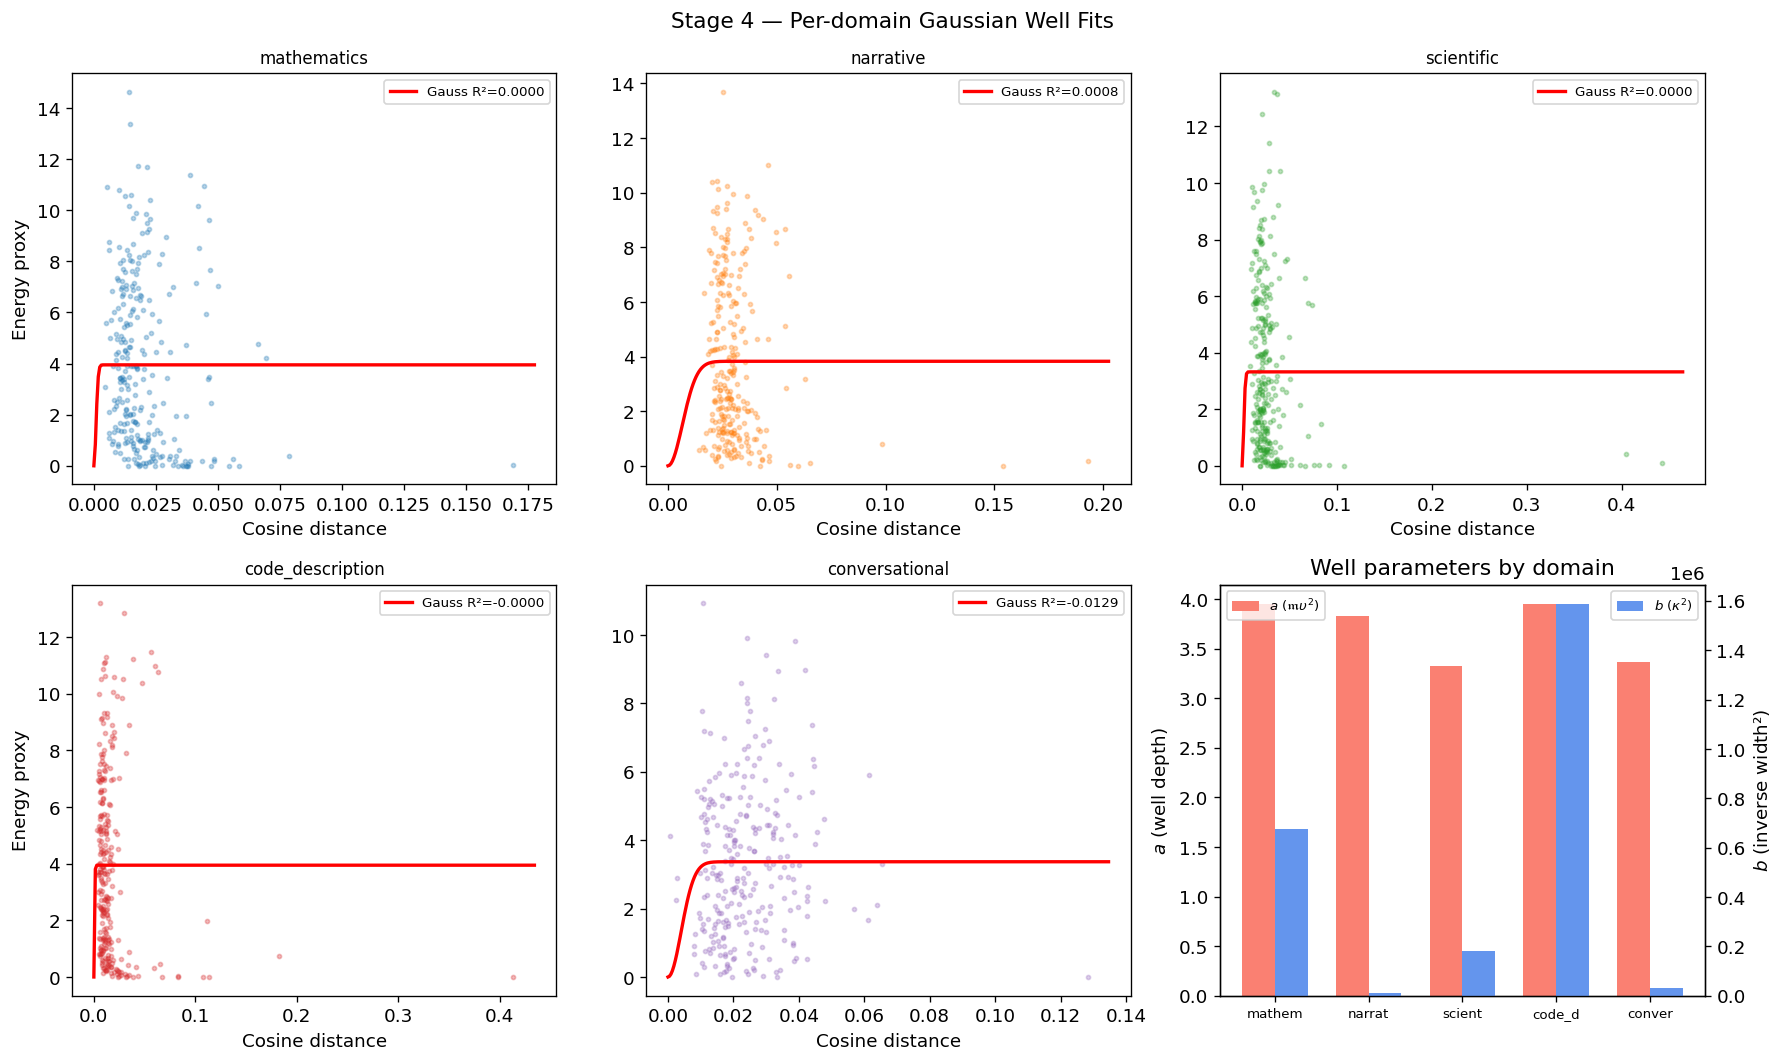

In [14]:
# ---- Per-domain scatter + Gaussian well fit ----

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, dom in enumerate(CORPUS.keys()):
    ax = axes[i]
    dom_trajs = [t for t in trajectories if t.domain == dom]
    d_arr = np.concatenate([t.distances for t in dom_trajs])
    e_arr = np.concatenate([t.per_token_loss for t in dom_trajs])
    ax.scatter(d_arr, e_arr, s=6, alpha=0.3, color=domain_colors[dom])

    gw = domain_fit_results[dom]["gaussian_well"]
    if gw["popt"] is not None:
        x_fit = np.linspace(0, d_arr.max() * 1.05, 300)
        ax.plot(x_fit, gaussian_well(x_fit, *gw["popt"]), "r-", lw=2,
                label=f"Gauss R²={gw['r2']:.4f}")
    ax.set_title(dom, fontsize=10)
    ax.set_xlabel("Cosine distance")
    ax.legend(fontsize=8)
    if i % 3 == 0:
        ax.set_ylabel("Energy proxy")

# Summary bar chart of a and b across domains
ax = axes[5]
doms = list(CORPUS.keys())
a_vals = []
b_vals = []
for dom in doms:
    gw = domain_fit_results[dom]["gaussian_well"]
    if gw["popt"] is not None:
        a_vals.append(gw["popt"][0])
        b_vals.append(gw["popt"][1])
    else:
        a_vals.append(0)
        b_vals.append(0)

x_pos = np.arange(len(doms))
width = 0.35
ax.bar(x_pos - width/2, a_vals, width, label="$a$ ($\\mathfrak{m}\\upsilon^2$)", color="salmon")
ax2 = ax.twinx()
ax2.bar(x_pos + width/2, b_vals, width, label="$b$ ($\\kappa^2$)", color="cornflowerblue")
ax.set_xticks(x_pos)
ax.set_xticklabels([d[:6] for d in doms], fontsize=8)
ax.set_ylabel("$a$ (well depth)")
ax2.set_ylabel("$b$ (inverse width²)")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
ax.set_title("Well parameters by domain")

fig.suptitle("Stage 4 — Per-domain Gaussian Well Fits", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage4_domain_fits.png"), dpi=150)
plt.show()

### 4.3 Restoring force analysis

The Gaussian well predicts a restoring force profile:

$$F(x) = -\frac{dV}{dx} = 2ab \cdot x \cdot e^{-bx^2}$$

We estimate the empirical force from the energy gradient and compare.

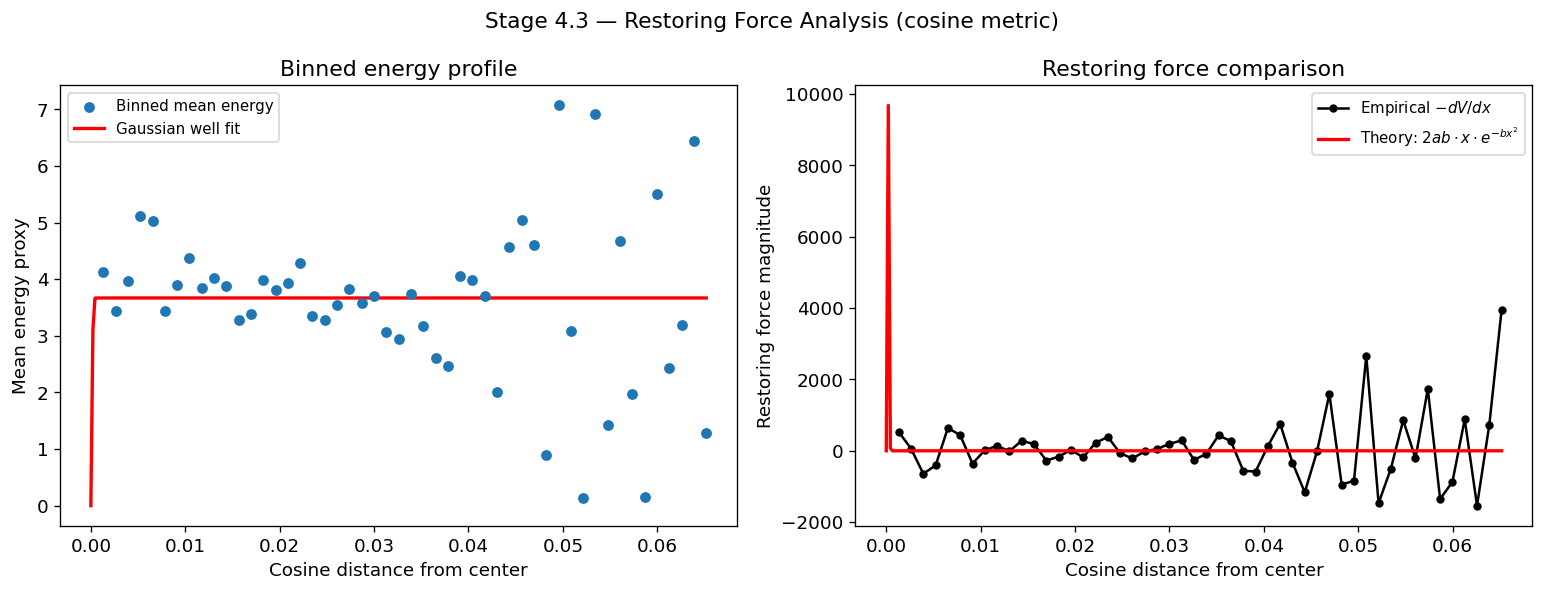

In [15]:
def theoretical_force(x, a, b):
    """Restoring force from the Gaussian well: F = -dV/dx = 2ab·x·exp(-bx²)."""
    return 2 * a * b * x * np.exp(-b * x**2)


# Bin the pooled data and estimate dV/dx numerically
n_bins = 50
sort_idx = np.argsort(all_d)
d_sorted = all_d[sort_idx]
e_sorted = all_e[sort_idx]

bin_edges = np.linspace(d_sorted.min(), np.percentile(d_sorted, 98), n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_means = np.zeros(n_bins)

for i in range(n_bins):
    mask = (all_d >= bin_edges[i]) & (all_d < bin_edges[i + 1])
    if mask.sum() > 0:
        bin_means[i] = all_e[mask].mean()
    else:
        bin_means[i] = np.nan

valid = ~np.isnan(bin_means)
empirical_force = -np.gradient(bin_means[valid], bin_centers[valid])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: binned energy curve
ax1.scatter(bin_centers[valid], bin_means[valid], s=30, zorder=3, label="Binned mean energy")
gw = global_fits["gaussian_well"]
if gw["popt"] is not None:
    x_th = np.linspace(0, bin_centers[valid].max(), 300)
    ax1.plot(x_th, gaussian_well(x_th, *gw["popt"]), "r-", lw=2, label="Gaussian well fit")
ax1.set_xlabel("Cosine distance from center")
ax1.set_ylabel("Mean energy proxy")
ax1.set_title("Binned energy profile")
ax1.legend(fontsize=9)

# Right: empirical vs theoretical force
ax2.plot(bin_centers[valid], empirical_force, "ko-", ms=4, label="Empirical $-dV/dx$")
if gw["popt"] is not None:
    a, b = gw["popt"]
    ax2.plot(x_th, theoretical_force(x_th, a, b), "r-", lw=2,
             label=f"Theory: $2ab \\cdot x \\cdot e^{{-bx^2}}$")
ax2.set_xlabel("Cosine distance from center")
ax2.set_ylabel("Restoring force magnitude")
ax2.set_title("Restoring force comparison")
ax2.legend(fontsize=9)

fig.suptitle("Stage 4.3 — Restoring Force Analysis (cosine metric)", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage4_restoring_force.png"), dpi=150)
plt.show()

---
## Stage 5 — Lagrangian Reconstruction and Action

Using the fitted Gaussian well as $V(h_t)$ and the angular velocity
$\omega_t = \arccos\bigl(\cos(h_t, h_{t-1})\bigr)$ between consecutive hidden
states, we reconstruct:

$$\mathcal{L}_t = T_t - V_t = \frac{1}{2}\,\omega_t^2 - V\bigl(d_{\cos}(h_t, c)\bigr)$$

$$\mathcal{S} = \sum_t \mathcal{L}_t$$

Angular velocity is the natural kinematic quantity when distance is measured
by cosine similarity.  (We set $\mathfrak{m} = 1$ and absorb it into $a$.)

In [16]:
@dataclass
class TrajectoryDynamics:
    velocities: np.ndarray       # (T-2,)  angular velocity arccos(cos(h_t, h_{t-1}))
    kinetic: np.ndarray          # (T-2,)  0.5 * ω²
    potential: np.ndarray        # (T-2,)  V(cosine_distance)
    lagrangian: np.ndarray       # (T-2,)  T - V
    action: float                # sum of lagrangian
    stp_loss: float              # mean STP loss over sampled triplets


def _pairwise_angular_velocity(hs):
    """Angular displacement between consecutive hidden states: arccos(cos(h_t, h_{t-1}))."""
    dots = np.sum(hs[1:] * hs[:-1], axis=1)
    norms = np.linalg.norm(hs[1:], axis=1) * np.linalg.norm(hs[:-1], axis=1) + 1e-12
    cos_sim = np.clip(dots / norms, -1.0, 1.0)
    return np.arccos(cos_sim)


def compute_dynamics(traj: Trajectory, a: float, b: float,
                     num_triplets: int = 500) -> TrajectoryDynamics:
    hs = traj.hidden_states  # (T, d)
    T = hs.shape[0]

    # Angular velocity between consecutive hidden states
    ang_vels = _pairwise_angular_velocity(hs)  # (T-1,)

    # Align: use positions 1..T-1 (which have both a velocity and a distance)
    vels_aligned = ang_vels[:-1]       # (T-2,) — angular velocity arriving at h_1..h_{T-2}
    dist_aligned = traj.distances[1:]  # (T-2,) — cosine distance of h_1..h_{T-2}

    kinetic = 0.5 * vels_aligned ** 2
    potential = gaussian_well(dist_aligned, a, b)
    lagrangian = kinetic - potential
    action = lagrangian.sum()

    # STP loss: sample random triplets (s, r, t) with s < r < t
    stp_values = []
    if T >= 3:
        rng = np.random.default_rng(42)
        for _ in range(min(num_triplets, T * (T - 1) * (T - 2) // 6)):
            idx = sorted(rng.choice(T, size=3, replace=False))
            s, r, t = idx
            v1 = hs[t] - hs[r]
            v2 = hs[r] - hs[s]
            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12)
            stp_values.append(1.0 - cos_sim)

    stp_loss = float(np.mean(stp_values)) if stp_values else 0.0

    return TrajectoryDynamics(
        velocities=vels_aligned,
        kinetic=kinetic,
        potential=potential,
        lagrangian=lagrangian,
        action=action,
        stp_loss=stp_loss,
    )

In [17]:
gw = global_fits["gaussian_well"]
if gw["popt"] is None:
    raise RuntimeError("Gaussian well fit failed — cannot proceed with Stage 5.")

a_global, b_global = gw["popt"]
print(f"Using global Gaussian well parameters: a={a_global:.6f}, b={b_global:.6f}")
print(f"  → well depth  (𝔪υ²) = {a_global:.4f}")
print(f"  → κ²                 = {b_global:.6f}")
print(f"  → κ                  = {np.sqrt(b_global):.6f}")
print(f"  → inflection point   = {1.0 / (np.sqrt(2 * b_global) + 1e-12):.4f}")

dynamics: list[TrajectoryDynamics] = []
for traj in tqdm(trajectories, desc="Computing dynamics"):
    dynamics.append(compute_dynamics(traj, a_global, b_global, cfg.num_stp_triplets))

actions = np.array([d.action for d in dynamics])
stp_losses = np.array([d.stp_loss for d in dynamics])

print(f"\nAction stats:     mean={actions.mean():.2f}, std={actions.std():.2f}")
print(f"STP loss stats:   mean={stp_losses.mean():.6f}, std={stp_losses.std():.6f}")

Using global Gaussian well parameters: a=3.669321, b=39425833.244444
  → well depth  (𝔪υ²) = 3.6693
  → κ²                 = 39425833.244444
  → κ                  = 6278.999382
  → inflection point   = 0.0001


Computing dynamics:   0%|          | 0/50 [00:00<?, ?it/s]


Action stats:     mean=-95.87, std=14.13
STP loss stats:   mean=1.333424, std=0.071584


### 5.1 Correlation between Action and STP Loss

**Prediction 4**: Trajectories with lower STP loss should also have lower total action,
if the STP loss is a proxy for deviation from the action-minimizing path.

Pearson  r = -0.2603  (p = 6.79e-02)
Spearman ρ = -0.2085  (p = 1.46e-01)


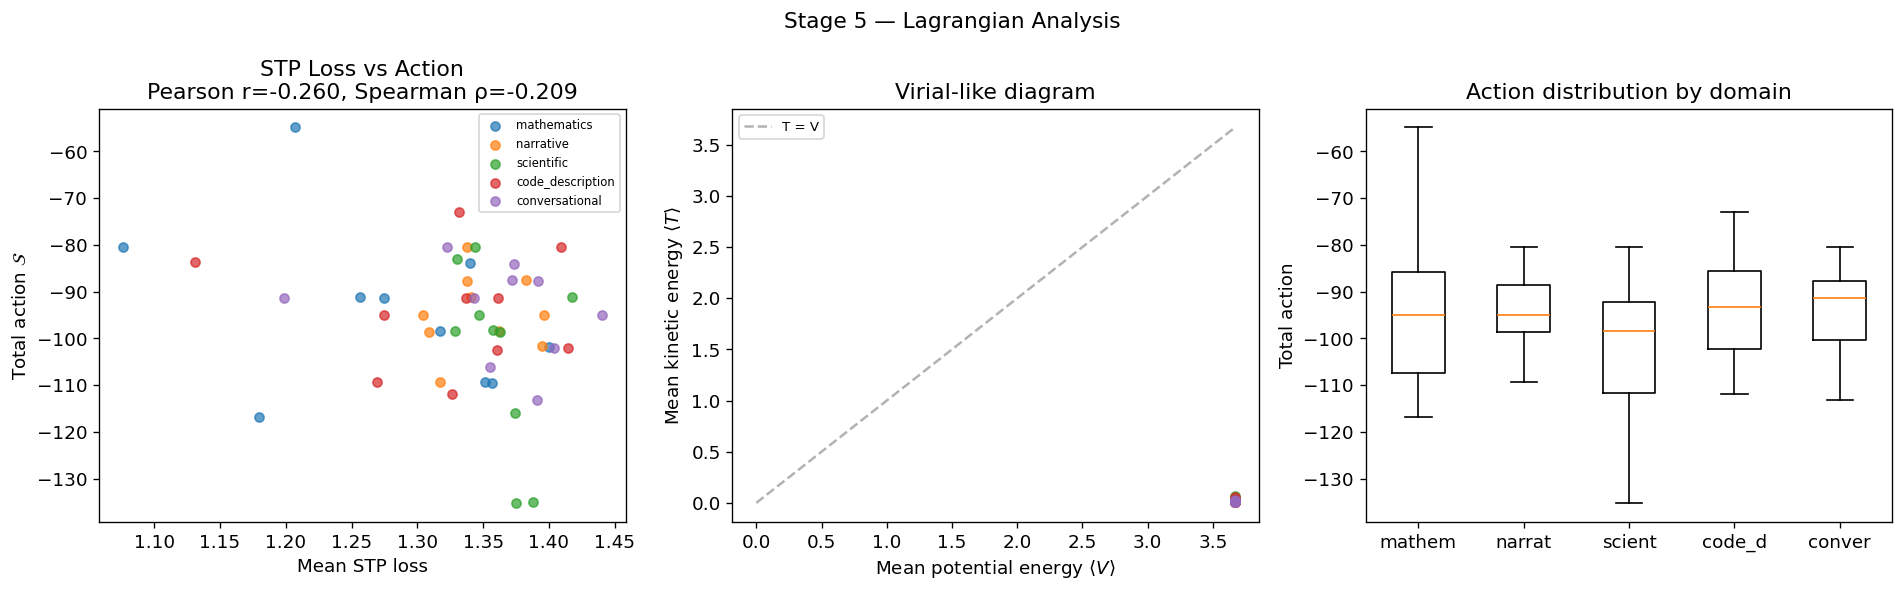

In [18]:
r_pearson, p_pearson = pearsonr(stp_losses, actions)
r_spearman, p_spearman = spearmanr(stp_losses, actions)

print(f"Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})")
print(f"Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.2e})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) STP loss vs Action scatter
ax = axes[0]
dom_arr = np.array(all_domains)
for dom in CORPUS.keys():
    mask = dom_arr == dom
    ax.scatter(stp_losses[mask], actions[mask], s=30, alpha=0.7,
               color=domain_colors[dom], label=dom)
ax.set_xlabel("Mean STP loss")
ax.set_ylabel("Total action $\\mathcal{S}$")
ax.set_title(f"STP Loss vs Action\nPearson r={r_pearson:.3f}, Spearman ρ={r_spearman:.3f}")
ax.legend(fontsize=7)

# 2) Kinetic vs Potential energy
ax = axes[1]
mean_T = np.array([d.kinetic.mean() for d in dynamics])
mean_V = np.array([d.potential.mean() for d in dynamics])
for dom in CORPUS.keys():
    mask = dom_arr == dom
    ax.scatter(mean_V[mask], mean_T[mask], s=30, alpha=0.7, color=domain_colors[dom])
ax.set_xlabel("Mean potential energy $\\langle V \\rangle$")
ax.set_ylabel("Mean kinetic energy $\\langle T \\rangle$")
ax.set_title("Virial-like diagram")
ax.plot([0, max(mean_V.max(), mean_T.max())],
        [0, max(mean_V.max(), mean_T.max())], "k--", alpha=0.3, label="T = V")
ax.legend(fontsize=8)

# 3) Action by domain
ax = axes[2]
domain_actions = {}
for dom in CORPUS.keys():
    mask = dom_arr == dom
    domain_actions[dom] = actions[mask]
ax.boxplot(
    [domain_actions[d] for d in CORPUS.keys()],
    tick_labels=[d[:6] for d in CORPUS.keys()],
)
ax.set_ylabel("Total action")
ax.set_title("Action distribution by domain")

fig.suptitle("Stage 5 — Lagrangian Analysis", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage5_lagrangian_analysis.png"), dpi=150)
plt.show()

### 5.2 Per-trajectory dynamics profile

Visualize kinetic, potential, and Lagrangian along individual trajectories.

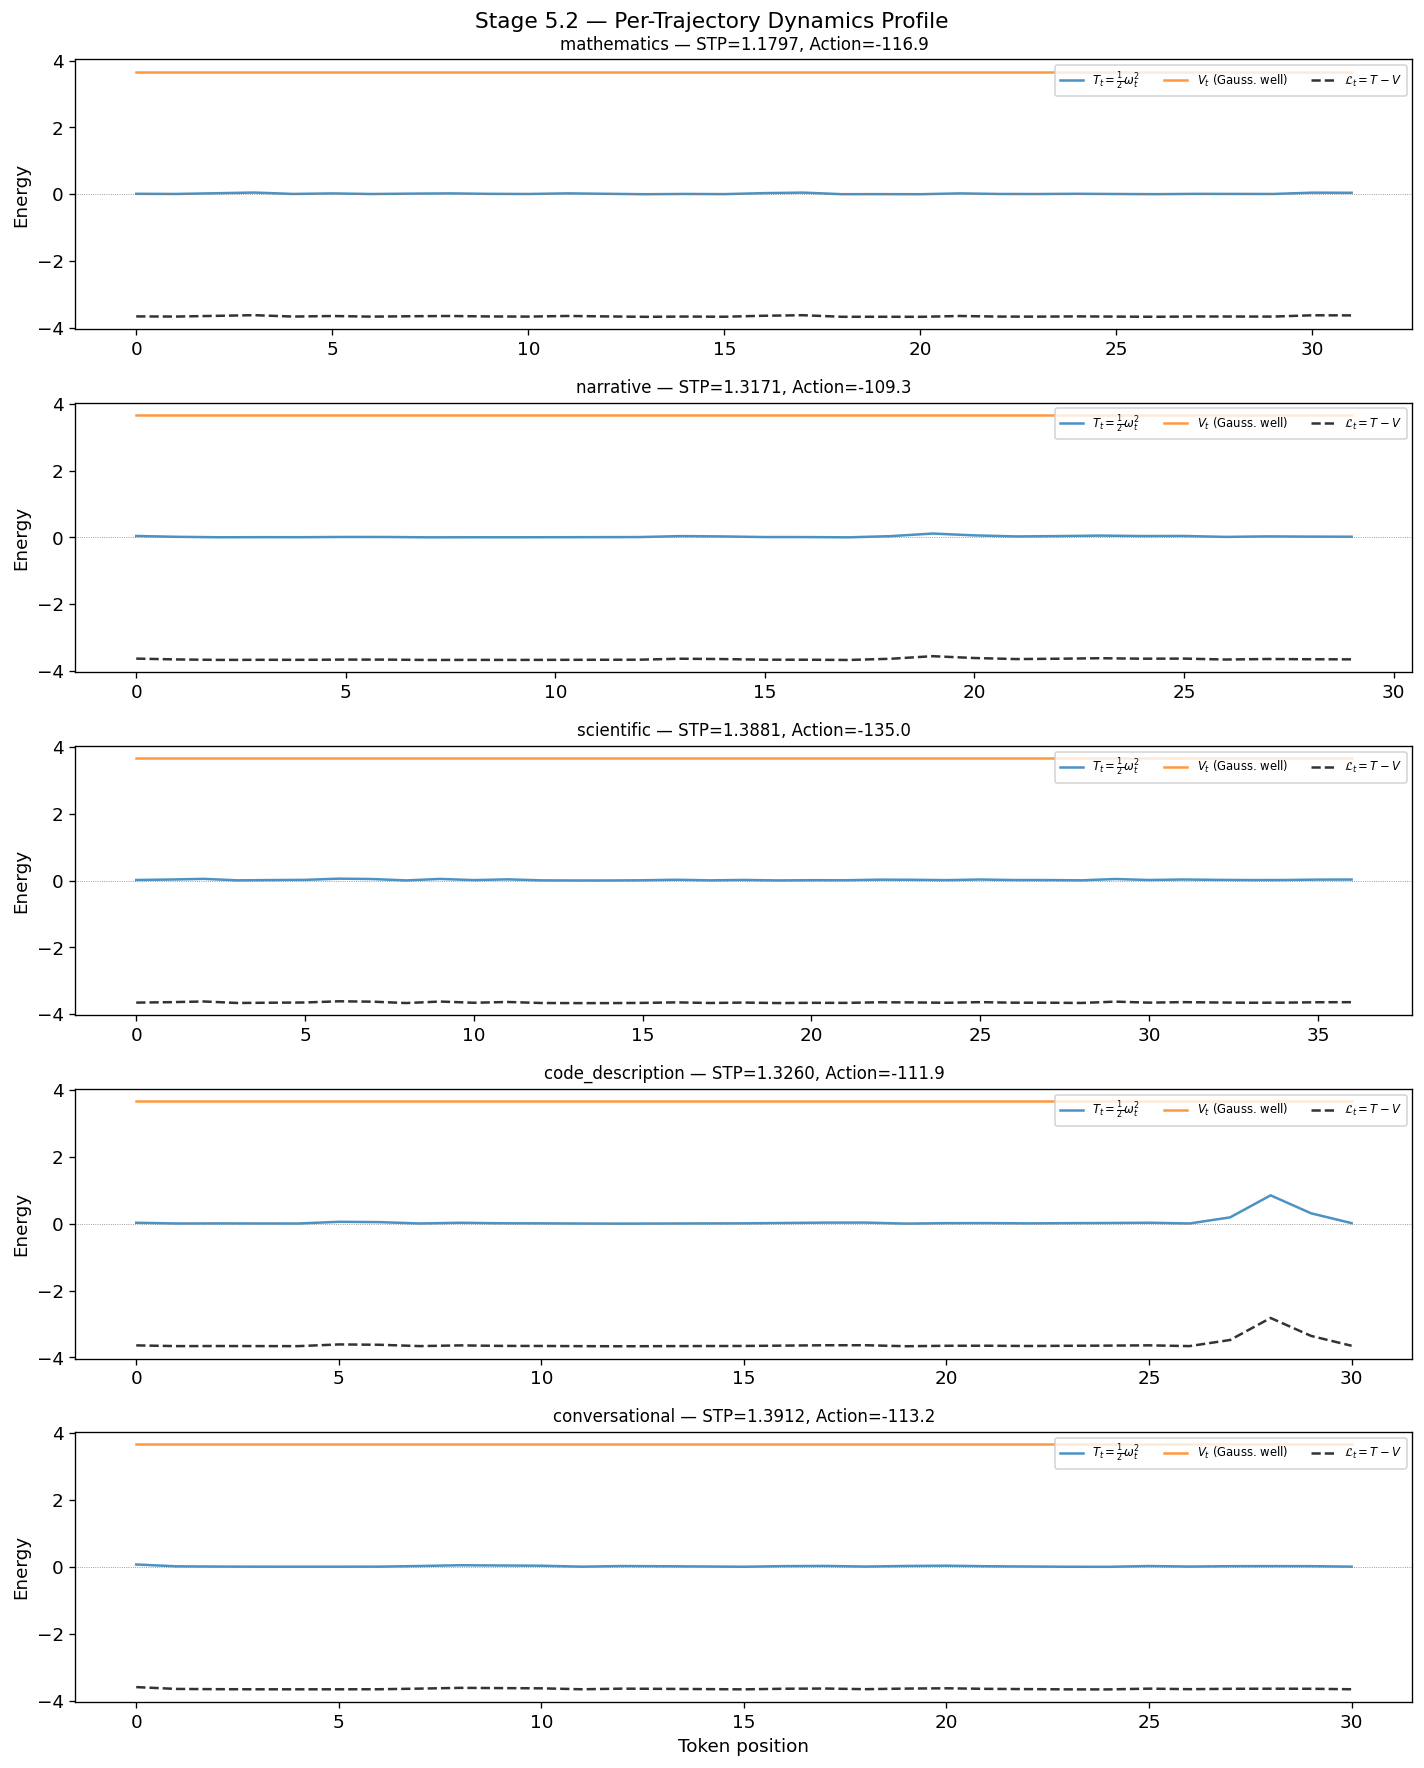

In [19]:
# Pick one trajectory from each domain with the most tokens
fig, axes = plt.subplots(len(CORPUS), 1, figsize=(12, 3 * len(CORPUS)), sharex=False)

for i, dom in enumerate(CORPUS.keys()):
    ax = axes[i]
    dom_indices = [j for j, t in enumerate(trajectories) if t.domain == dom]
    best_j = max(dom_indices, key=lambda j: len(dynamics[j].lagrangian))
    d = dynamics[best_j]

    ts = np.arange(len(d.lagrangian))
    ax.plot(ts, d.kinetic, label="$T_t = \\frac{1}{2}\\omega_t^2$", alpha=0.8)
    ax.plot(ts, d.potential, label="$V_t$ (Gauss. well)", alpha=0.8)
    ax.plot(ts, d.lagrangian, label="$\\mathcal{L}_t = T - V$", alpha=0.8, color="black", ls="--")
    ax.axhline(0, color="gray", ls=":", lw=0.5)
    ax.set_ylabel("Energy")
    ax.set_title(f"{dom} — STP={dynamics[best_j].stp_loss:.4f}, Action={dynamics[best_j].action:.1f}",
                 fontsize=10)
    ax.legend(fontsize=7, ncol=3, loc="upper right")

axes[-1].set_xlabel("Token position")
fig.suptitle("Stage 5.2 — Per-Trajectory Dynamics Profile", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage5_trajectory_profiles.png"), dpi=150)
plt.show()

---
## Stage 6 — Acceleration–STP Equivalence (Action Plan Step 1)

This stage implements **Step 1** of the Prioritized Action Plan from
`docs/On_The_Existence_of_Acceleration_in_Semantic_Structures.md` (Section 8.1).

For each **consecutive** triplet $(t-1, t, t+1)$ we compute:

1. Displacement vectors $\vec{d}_1 = h_t - h_{t-1}$ and $\vec{d}_2 = h_{t+1} - h_t$
2. Discrete acceleration $\vec{a} = \vec{d}_2 - \vec{d}_1 = h_{t+1} - 2h_t + h_{t-1}$
3. Normal component $\vec{a}_\perp$ (perpendicular to $\vec{d}_1$) and tangential component $\vec{a}_\parallel$ (along $\vec{d}_1$)
4. Per-triplet STP loss $\mathcal{L}_{STP} = 1 - \cos(\vec{d}_2, \vec{d}_1)$

**Exact relationship to verify** (Section 2.1.3 of the acceleration document):

$$\mathcal{L}_{STP} = 1 - \sqrt{1 - \frac{|\vec{a}_\perp|^2}{|\vec{d}_2|^2}}$$

**Total acceleration decomposition** (Section 2.1.4):

$$|\vec{a}|^2 = (|\vec{d}_2| - |\vec{d}_1|)^2 + 2|\vec{d}_1||\vec{d}_2| \cdot \mathcal{L}_{STP}$$

In [20]:
@dataclass
class AccelerationResult:
    """Acceleration decomposition for one consecutive triplet (t-1, t, t+1)."""
    a_parallel: float       # signed tangential acceleration (>0 = speeding up along d_1)
    a_perp_mag: float       # |a_perp| (normal acceleration magnitude)
    stp_loss: float         # actual: 1 - cos(d_2, d_1)
    stp_predicted: float    # from |a_perp| and |d_2| via the exact formula
    speed_d1: float         # |d_1|
    speed_d2: float         # |d_2|
    accel_mag: float        # |a| total


@dataclass
class TrajectoryAcceleration:
    """Acceleration analysis for one trajectory."""
    triplets: list
    mean_stp: float
    mean_a_perp: float
    mean_a_parallel_abs: float
    ratio_parallel_to_perp: float


def decompose_acceleration(h_prev, h_curr, h_next):
    """Decompose acceleration at position t into normal and tangential components.

    Following Section 2.1.2 of the acceleration document:
      d_1 = h_t - h_{t-1},  d_2 = h_{t+1} - h_t,  a = d_2 - d_1
    Decompose d_2 into components parallel/perpendicular to d_1:
      a_perp  = d_{2,perp}            with |a_perp| = |d_2| sin(theta)
      a_par   = |d_2| cos(theta) - |d_1|  (signed scalar)
    """
    d1 = h_curr - h_prev
    d2 = h_next - h_curr

    norm_d1 = np.linalg.norm(d1) + 1e-12
    norm_d2 = np.linalg.norm(d2) + 1e-12

    cos_theta = np.clip(np.dot(d1, d2) / (norm_d1 * norm_d2), -1.0, 1.0)
    sin_theta = np.sqrt(1.0 - cos_theta ** 2)

    stp = 1.0 - cos_theta
    a_perp_mag = norm_d2 * sin_theta
    a_par = norm_d2 * cos_theta - norm_d1

    ratio = min(a_perp_mag ** 2 / (norm_d2 ** 2), 1.0)
    stp_pred = 1.0 - np.sqrt(max(1.0 - ratio, 0.0)) if cos_theta >= 0 else \
               1.0 + np.sqrt(max(1.0 - ratio, 0.0))

    accel = d2 - d1
    return AccelerationResult(
        a_parallel=float(a_par),
        a_perp_mag=float(a_perp_mag),
        stp_loss=float(stp),
        stp_predicted=float(stp_pred),
        speed_d1=float(norm_d1),
        speed_d2=float(norm_d2),
        accel_mag=float(np.linalg.norm(accel)),
    )


def analyze_trajectory_acceleration(traj: Trajectory) -> TrajectoryAcceleration:
    """Compute acceleration decomposition for all consecutive triplets."""
    hs = traj.hidden_states
    T = hs.shape[0]

    triplets = [decompose_acceleration(hs[t - 1], hs[t], hs[t + 1]) for t in range(1, T - 1)]

    stps = np.array([r.stp_loss for r in triplets])
    a_perps = np.array([r.a_perp_mag for r in triplets])
    a_pars = np.array([abs(r.a_parallel) for r in triplets])

    mean_a_perp = a_perps.mean() if len(a_perps) > 0 else 0.0
    mean_a_par = a_pars.mean() if len(a_pars) > 0 else 0.0

    return TrajectoryAcceleration(
        triplets=triplets,
        mean_stp=float(stps.mean()) if len(stps) > 0 else 0.0,
        mean_a_perp=float(mean_a_perp),
        mean_a_parallel_abs=float(mean_a_par),
        ratio_parallel_to_perp=float(mean_a_par / (mean_a_perp + 1e-12)),
    )

In [21]:
accel_results: list[TrajectoryAcceleration] = []
for traj in tqdm(trajectories, desc="Analyzing acceleration"):
    accel_results.append(analyze_trajectory_acceleration(traj))

all_triplets = [tr for ar in accel_results for tr in ar.triplets]
print(f"Total consecutive triplets analyzed: {len(all_triplets)}")

all_stp_consec = np.array([t.stp_loss for t in all_triplets])
all_stp_pred = np.array([t.stp_predicted for t in all_triplets])
all_a_perp = np.array([t.a_perp_mag for t in all_triplets])
all_a_par_signed = np.array([t.a_parallel for t in all_triplets])
all_a_par_abs = np.abs(all_a_par_signed)
all_a_mag = np.array([t.accel_mag for t in all_triplets])
all_speed_d1 = np.array([t.speed_d1 for t in all_triplets])
all_speed_d2 = np.array([t.speed_d2 for t in all_triplets])

print(f"\nConsecutive-triplet STP loss:  mean={all_stp_consec.mean():.6f}, std={all_stp_consec.std():.6f}")
print(f"STP predicted (from a_perp):  mean={all_stp_pred.mean():.6f}, std={all_stp_pred.std():.6f}")
print(f"|a_perp|  (normal accel):     mean={all_a_perp.mean():.6f}, std={all_a_perp.std():.6f}")
print(f"|a_par|   (tangential, abs):  mean={all_a_par_abs.mean():.6f}, std={all_a_par_abs.std():.6f}")
print(f"a_par     (tangential, sign): mean={all_a_par_signed.mean():.6f}, std={all_a_par_signed.std():.6f}")
print(f"|a| total:                    mean={all_a_mag.mean():.6f}, std={all_a_mag.std():.6f}")
print(f"|d_1| (speed):                mean={all_speed_d1.mean():.6f}, std={all_speed_d1.std():.6f}")
print(f"|d_2| (speed):                mean={all_speed_d2.mean():.6f}, std={all_speed_d2.std():.6f}")

Analyzing acceleration:   0%|          | 0/50 [00:00<?, ?it/s]

Total consecutive triplets analyzed: 1314

Consecutive-triplet STP loss:  mean=1.377888, std=0.483385
STP predicted (from a_perp):  mean=1.377888, std=0.483385
|a_perp|  (normal accel):     mean=44.203649, std=24.184107
|a_par|   (tangential, abs):  mean=92.465751, std=65.574174
a_par     (tangential, sign): mean=-91.713837, std=66.621764
|a| total:                    mean=108.069369, std=60.907573
|d_1| (speed):                mean=64.063825, std=38.624246
|d_2| (speed):                mean=62.648428, std=35.641270


### 6.1 Verifying the Exact STP–Acceleration Equivalence

The derivation shows $\mathcal{L}_{STP} = 1 - \sqrt{1 - |\vec{a}_\perp|^2/|\vec{d}_2|^2}$
(for $\cos\theta \geq 0$). Since both sides are computed from the same angle $\theta$,
the relationship is an algebraic identity. The scatter plot should lie exactly on the
identity line (to numerical precision).

We also verify the total acceleration decomposition:
$|\vec{a}|^2 = (|\vec{d}_2|-|\vec{d}_1|)^2 + 2|\vec{d}_1||\vec{d}_2|\mathcal{L}_{STP}$

=== STP–Acceleration Equivalence Verification ===
Pearson r (actual vs predicted STP):  1.0000000000
Max absolute error:                   1.68e-13
Mean absolute error:                  4.74e-16
The exact relationship is confirmed to numerical precision.

=== Total Acceleration Decomposition Verification ===
Max  |a|^2 decomposition error:  2.38e-02
Mean |a|^2 decomposition error:  1.21e-03


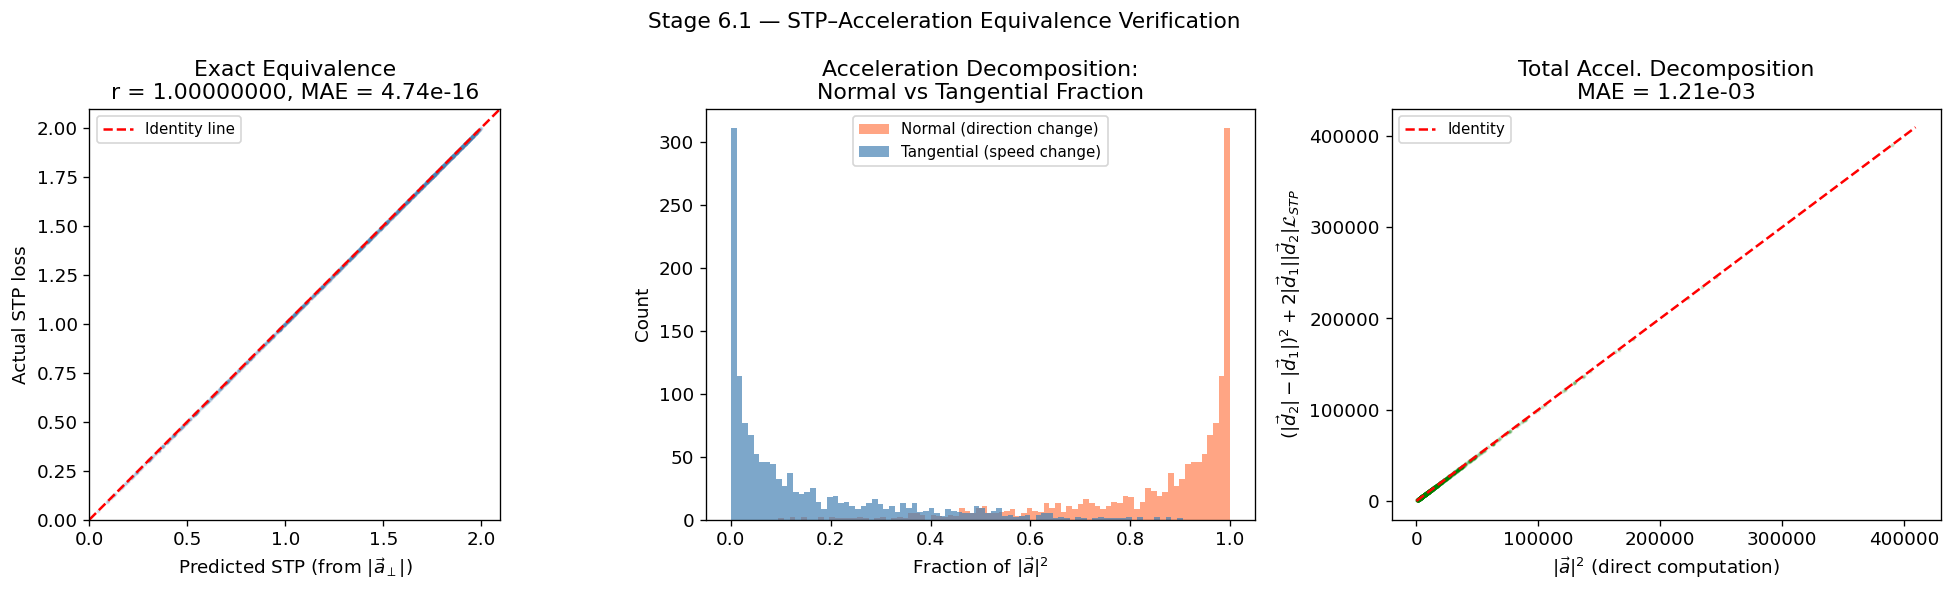

In [22]:
# --- 6.1  STP–Acceleration Equivalence ---

r_equiv, p_equiv = pearsonr(all_stp_consec, all_stp_pred)
max_err = np.max(np.abs(all_stp_consec - all_stp_pred))
mean_err = np.mean(np.abs(all_stp_consec - all_stp_pred))

print("=== STP–Acceleration Equivalence Verification ===")
print(f"Pearson r (actual vs predicted STP):  {r_equiv:.10f}")
print(f"Max absolute error:                   {max_err:.2e}")
print(f"Mean absolute error:                  {mean_err:.2e}")
if r_equiv > 0.9999:
    print("The exact relationship is confirmed to numerical precision.")
else:
    print("Significant deviation detected — investigate.")

# Total acceleration decomposition: |a|^2 = (|d2|-|d1|)^2 + 2|d1||d2| L_STP
lhs = all_a_mag ** 2
speed_change_sq = (all_speed_d2 - all_speed_d1) ** 2
direction_change = 2 * all_speed_d1 * all_speed_d2 * all_stp_consec
rhs = speed_change_sq + direction_change
decomp_err = np.abs(lhs - rhs)

print(f"\n=== Total Acceleration Decomposition Verification ===")
print(f"Max  |a|^2 decomposition error:  {decomp_err.max():.2e}")
print(f"Mean |a|^2 decomposition error:  {decomp_err.mean():.2e}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) STP actual vs predicted
ax = axes[0]
ax.scatter(all_stp_pred, all_stp_consec, s=2, alpha=0.15, color="steelblue")
lims = [0, max(all_stp_consec.max(), all_stp_pred.max()) * 1.05]
ax.plot(lims, lims, "r--", lw=1.5, label="Identity line")
ax.set_xlabel("Predicted STP (from $|\\vec{a}_\\perp|$)")
ax.set_ylabel("Actual STP loss")
ax.set_title(f"Exact Equivalence\nr = {r_equiv:.8f}, MAE = {mean_err:.2e}")
ax.legend(fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")

# (b) Fraction of |a|^2: normal vs tangential
frac_tangential = speed_change_sq / (lhs + 1e-12)
frac_normal = direction_change / (lhs + 1e-12)
ax = axes[1]
ax.hist(frac_normal, bins=80, alpha=0.7, color="coral", label="Normal (direction change)")
ax.hist(frac_tangential, bins=80, alpha=0.7, color="steelblue", label="Tangential (speed change)")
ax.set_xlabel("Fraction of $|\\vec{a}|^2$")
ax.set_ylabel("Count")
ax.set_title("Acceleration Decomposition:\nNormal vs Tangential Fraction")
ax.legend(fontsize=9)

# (c) |a|^2 decomposition identity
ax = axes[2]
ax.scatter(lhs, rhs, s=2, alpha=0.15, color="green")
lims2 = [0, max(lhs.max(), rhs.max()) * 1.05]
ax.plot(lims2, lims2, "r--", lw=1.5, label="Identity")
ax.set_xlabel("$|\\vec{a}|^2$ (direct computation)")
ax.set_ylabel("$(|\\vec{d}_2|-|\\vec{d}_1|)^2 + 2|\\vec{d}_1||\\vec{d}_2|\\mathcal{L}_{STP}$")
ax.set_title(f"Total Accel. Decomposition\nMAE = {decomp_err.mean():.2e}")
ax.legend(fontsize=9)

fig.suptitle("Stage 6.1 — STP–Acceleration Equivalence Verification", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage6_stp_acceleration_equivalence.png"), dpi=150)
plt.show()

### 6.2 Tangential Acceleration: Is It Systematically Present?

The STP loss is blind to tangential acceleration (speed changes along the trajectory).
If a Gaussian well potential governs the dynamics, tangential acceleration **must** exist
(Section 2.1.8 of the acceleration document).

We test:
1. **Basic statistics**: Is $|a_\parallel| \neq 0$ and of comparable magnitude to $|a_\perp|$?
2. **Permutation null**: Is the observed tangential acceleration different from what
   a random reordering of hidden states would produce? (Destroying sequential structure
   while preserving the marginal distribution.)

In [23]:
# --- 6.2  Tangential Acceleration Statistics ---

ratio_per_traj = np.array([ar.ratio_parallel_to_perp for ar in accel_results])

print("=== Tangential Acceleration Statistics ===")
print(f"|a_par|/|a_perp| per trajectory:  mean={ratio_per_traj.mean():.4f}, "
      f"median={np.median(ratio_per_traj):.4f}, std={ratio_per_traj.std():.4f}")
print(f"|a_par|/|a_perp| all triplets:    {all_a_par_abs.mean() / (all_a_perp.mean() + 1e-12):.4f}")
print(f"\nSigned a_parallel distribution:")
print(f"  mean  = {all_a_par_signed.mean():.6f}")
print(f"  std   = {all_a_par_signed.std():.6f}")
print(f"  frac > 0 (speeding up)  = {(all_a_par_signed > 0).mean():.3f}")
print(f"  frac < 0 (slowing down) = {(all_a_par_signed < 0).mean():.3f}")

# --- Permutation null test (vectorized) ---
n_perms = 100
rng = np.random.default_rng(42)
null_a_par_means = []
null_a_perp_means = []

for _ in tqdm(range(n_perms), desc="Permutation null"):
    perm_a_pars = []
    perm_a_perps = []
    for traj in trajectories:
        hs = traj.hidden_states
        idx = rng.permutation(hs.shape[0])
        hp = hs[idx]
        d1 = hp[1:-1] - hp[:-2]
        d2 = hp[2:] - hp[1:-1]
        n1 = np.linalg.norm(d1, axis=1) + 1e-12
        n2 = np.linalg.norm(d2, axis=1) + 1e-12
        cos_th = np.clip(np.sum(d1 * d2, axis=1) / (n1 * n2), -1.0, 1.0)
        sin_th = np.sqrt(1.0 - cos_th ** 2)
        perm_a_pars.append(np.abs(n2 * cos_th - n1))
        perm_a_perps.append(n2 * sin_th)
    null_a_par_means.append(np.mean(np.concatenate(perm_a_pars)))
    null_a_perp_means.append(np.mean(np.concatenate(perm_a_perps)))

null_a_par_means = np.array(null_a_par_means)
null_a_perp_means = np.array(null_a_perp_means)
obs_a_par = all_a_par_abs.mean()
obs_a_perp = all_a_perp.mean()

z_par = (obs_a_par - null_a_par_means.mean()) / (null_a_par_means.std() + 1e-12)
z_perp = (obs_a_perp - null_a_perp_means.mean()) / (null_a_perp_means.std() + 1e-12)
p_par = (null_a_par_means >= obs_a_par).mean()
p_perp = (null_a_perp_means >= obs_a_perp).mean()

print(f"\n=== Permutation Null Test (n_perms={n_perms}) ===")
print(f"{'':28s} {'Observed':>12s} {'Null mean':>12s} {'Null std':>12s} {'z-score':>10s} {'p-value':>10s}")
print("-" * 88)
print(f"{'Mean |a_parallel|':28s} {obs_a_par:12.6f} {null_a_par_means.mean():12.6f} "
      f"{null_a_par_means.std():12.6f} {z_par:10.2f} {p_par:10.4f}")
print(f"{'Mean |a_perp|':28s} {obs_a_perp:12.6f} {null_a_perp_means.mean():12.6f} "
      f"{null_a_perp_means.std():12.6f} {z_perp:10.2f} {p_perp:10.4f}")

if abs(z_par) > 3:
    print(f"\nTangential acceleration is significantly different from the permuted null (|z| = {abs(z_par):.1f} > 3).")
else:
    print(f"\nTangential acceleration is NOT significantly different from null (|z| = {abs(z_par):.1f}).")

=== Tangential Acceleration Statistics ===
|a_par|/|a_perp| per trajectory:  mean=2.0918, median=2.0996, std=0.2543
|a_par|/|a_perp| all triplets:    2.0918

Signed a_parallel distribution:
  mean  = -91.713837
  std   = 66.621764
  frac > 0 (speeding up)  = 0.021
  frac < 0 (slowing down) = 0.979


Permutation null:   0%|          | 0/100 [00:00<?, ?it/s]


=== Permutation Null Test (n_perms=100) ===
                                 Observed    Null mean     Null std    z-score    p-value
----------------------------------------------------------------------------------------
Mean |a_parallel|               92.465751   115.826691     1.974919     -11.83     1.0000
Mean |a_perp|                   44.203649    48.802406     0.383010     -12.01     1.0000

Tangential acceleration is significantly different from the permuted null (|z| = 11.8 > 3).


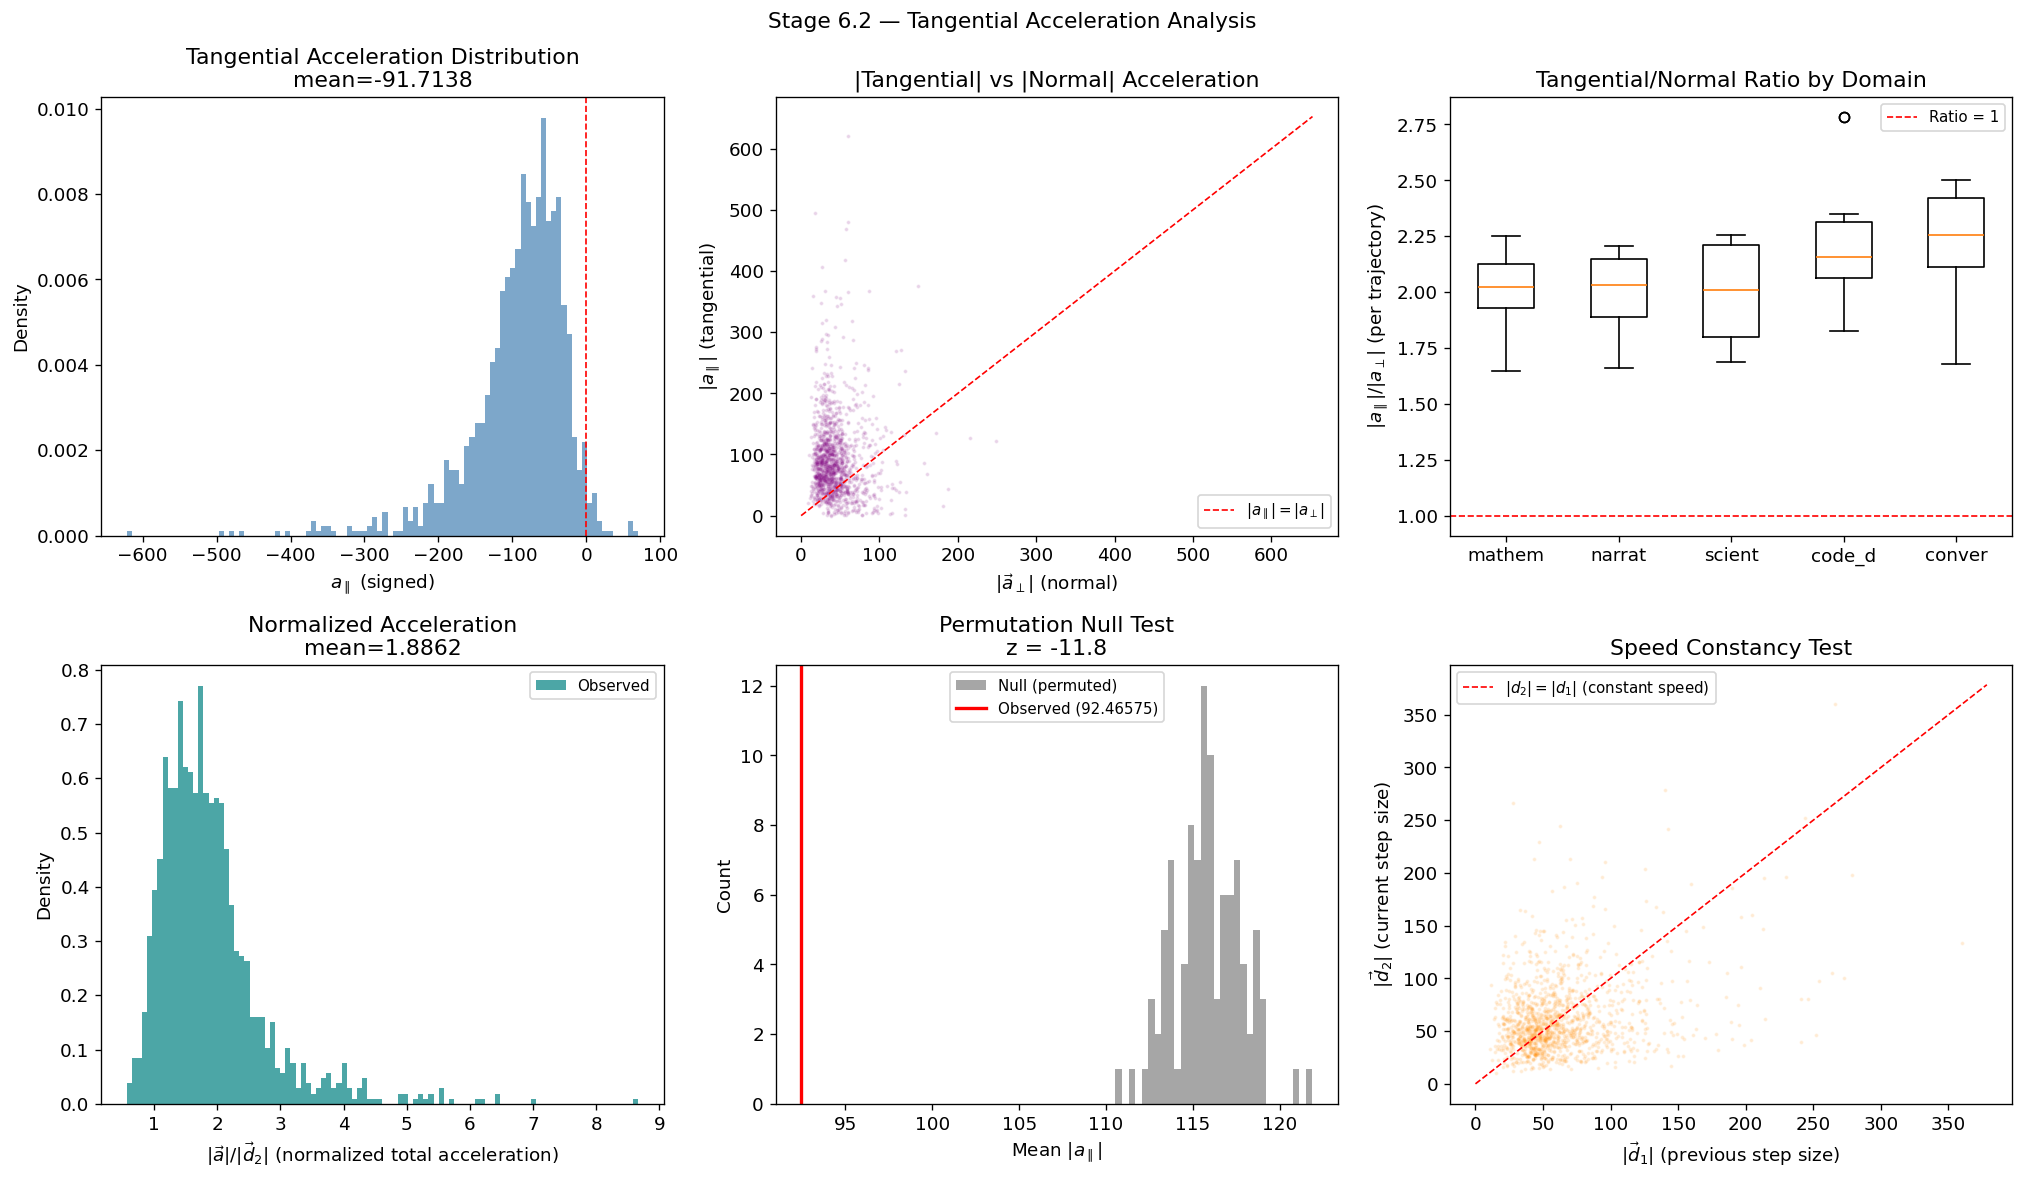

In [24]:
# --- 6.2  Tangential Acceleration Visualizations ---

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# (a) Signed a_parallel distribution
ax = axes[0, 0]
ax.hist(all_a_par_signed, bins=100, density=True, alpha=0.7, color="steelblue")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel("$a_\\parallel$ (signed)")
ax.set_ylabel("Density")
ax.set_title(f"Tangential Acceleration Distribution\nmean={all_a_par_signed.mean():.4f}")

# (b) |a_parallel| vs |a_perp| scatter
ax = axes[0, 1]
ax.scatter(all_a_perp, all_a_par_abs, s=2, alpha=0.1, color="purple")
mx = max(all_a_perp.max(), all_a_par_abs.max()) * 1.05
ax.plot([0, mx], [0, mx], "r--", lw=1, label="$|a_\\parallel| = |a_\\perp|$")
ax.set_xlabel("$|\\vec{a}_\\perp|$ (normal)")
ax.set_ylabel("$|a_\\parallel|$ (tangential)")
ax.set_title("|Tangential| vs |Normal| Acceleration")
ax.legend(fontsize=9)

# (c) |a_par|/|a_perp| ratio per trajectory by domain
ax = axes[0, 2]
dom_ratios = {}
dom_arr = np.array(all_domains)
for dom in CORPUS.keys():
    mask = dom_arr == dom
    dom_ratios[dom] = ratio_per_traj[mask]
ax.boxplot(
    [dom_ratios[d] for d in CORPUS.keys()],
    tick_labels=[d[:6] for d in CORPUS.keys()],
)
ax.axhline(1.0, color="red", ls="--", lw=1, label="Ratio = 1")
ax.set_ylabel("$|a_\\parallel| / |a_\\perp|$ (per trajectory)")
ax.set_title("Tangential/Normal Ratio by Domain")
ax.legend(fontsize=9)

# (d) Normalized acceleration |a|/|v| distribution (observed vs null)
norm_accel = all_a_mag / (all_speed_d2 + 1e-12)
ax = axes[1, 0]
ax.hist(norm_accel, bins=100, density=True, alpha=0.7, color="teal", label="Observed")
ax.set_xlabel("$|\\vec{a}| / |\\vec{d}_2|$ (normalized total acceleration)")
ax.set_ylabel("Density")
ax.set_title(f"Normalized Acceleration\nmean={norm_accel.mean():.4f}")
ax.legend(fontsize=9)

# (e) Permutation null comparison
ax = axes[1, 1]
ax.hist(null_a_par_means, bins=30, alpha=0.7, color="gray", label="Null (permuted)")
ax.axvline(obs_a_par, color="red", lw=2, label=f"Observed ({obs_a_par:.5f})")
ax.set_xlabel("Mean $|a_\\parallel|$")
ax.set_ylabel("Count")
ax.set_title(f"Permutation Null Test\nz = {z_par:.1f}")
ax.legend(fontsize=9)

# (f) Speed profile: |d_1| vs |d_2| — if constant speed, points lie on identity
ax = axes[1, 2]
ax.scatter(all_speed_d1, all_speed_d2, s=2, alpha=0.1, color="darkorange")
sm = max(all_speed_d1.max(), all_speed_d2.max()) * 1.05
ax.plot([0, sm], [0, sm], "r--", lw=1, label="$|d_2| = |d_1|$ (constant speed)")
ax.set_xlabel("$|\\vec{d}_1|$ (previous step size)")
ax.set_ylabel("$|\\vec{d}_2|$ (current step size)")
ax.set_title("Speed Constancy Test")
ax.legend(fontsize=9)

fig.suptitle("Stage 6.2 — Tangential Acceleration Analysis", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage6_tangential_acceleration.png"), dpi=150)
plt.show()

### 6.3 Per-Trajectory Acceleration Profiles

Visualize how normal and tangential acceleration vary along individual trajectories
(one per domain, selecting the longest trajectory).

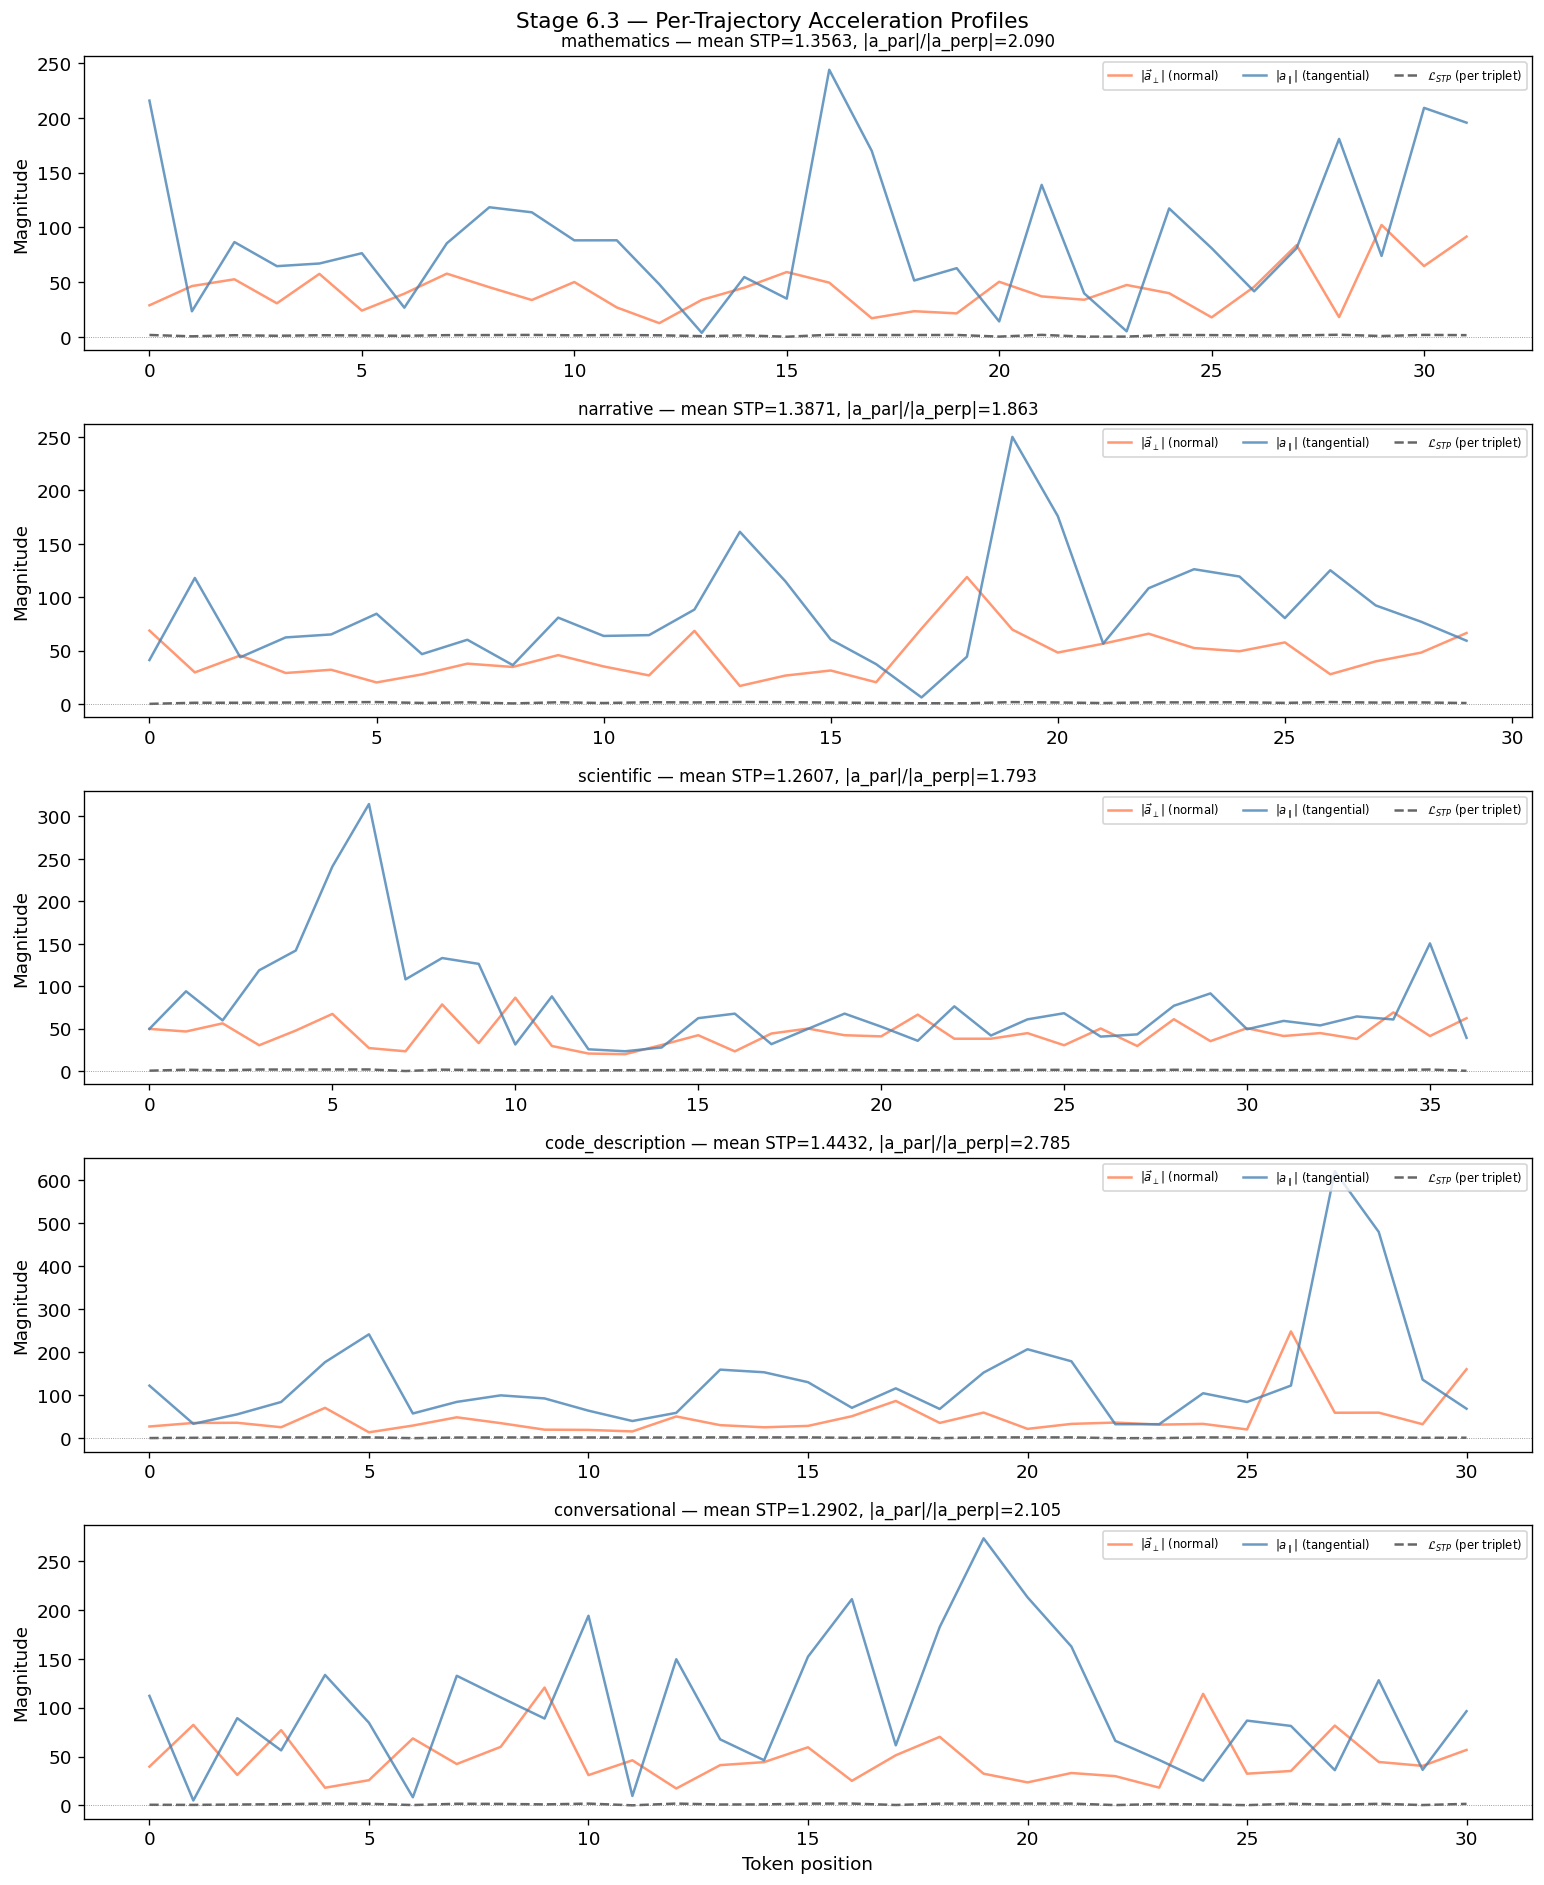

In [25]:
# --- 6.3  Per-Trajectory Acceleration Profiles ---

fig, axes = plt.subplots(len(CORPUS), 1, figsize=(13, 3.2 * len(CORPUS)), sharex=False)

for i, dom in enumerate(CORPUS.keys()):
    ax = axes[i]
    dom_indices = [j for j, t in enumerate(trajectories) if t.domain == dom]
    best_j = max(dom_indices, key=lambda j: len(accel_results[j].triplets))
    ar = accel_results[best_j]

    ts = np.arange(len(ar.triplets))
    a_perps_t = np.array([t.a_perp_mag for t in ar.triplets])
    a_pars_t = np.array([t.a_parallel for t in ar.triplets])
    stps_t = np.array([t.stp_loss for t in ar.triplets])

    ax.plot(ts, a_perps_t, label="$|\\vec{a}_\\perp|$ (normal)", alpha=0.8, color="coral")
    ax.plot(ts, np.abs(a_pars_t), label="$|a_\\parallel|$ (tangential)", alpha=0.8, color="steelblue")
    ax.plot(ts, stps_t, label="$\\mathcal{L}_{STP}$ (per triplet)", alpha=0.6, color="black", ls="--")
    ax.axhline(0, color="gray", ls=":", lw=0.5)
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{dom} — mean STP={ar.mean_stp:.4f}, |a_par|/|a_perp|={ar.ratio_parallel_to_perp:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7, ncol=3, loc="upper right")

axes[-1].set_xlabel("Token position")
fig.suptitle("Stage 6.3 — Per-Trajectory Acceleration Profiles", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage6_trajectory_acceleration_profiles.png"), dpi=150)
plt.show()

---
## Summary and Next Steps

### Results collected

| Quantity | Value |
|----------|-------|
| Gaussian well R² (global) | *see Stage 4 above* |
| Harmonic R² (global) | *see Stage 4 above* |
| Pearson r (STP loss, Action) | *see Stage 5 above* |
| Spearman ρ (STP loss, Action) | *see Stage 5 above* |
| STP–acceleration equivalence (Pearson r) | *see Stage 6.1 above* |
| Mean tangential/normal ratio | *see Stage 6.2 above* |
| Permutation null z-score (tangential) | *see Stage 6.2 above* |

### Interpretation guide

- **Gaussian R² ≫ Harmonic R²** → evidence for bounded, saturating potential (supports conjecture)
- **Pearson r > 0 and significant** → STP loss correlates with action (supports Prediction 4)
- **Well parameters vary by domain** → semantic content encoded in energy landscape (supports Prediction 5)
- **STP–acceleration r ≈ 1** → exact algebraic identity confirmed (validates Resolution 2.1)
- **|a_parallel|/|a_perp| of order 1** → tangential acceleration comparable to normal (Section 2.1.8)
- **Permutation z > 3** → sequential structure produces systematically different acceleration than random

### Next steps

1. **Scale up**: Switch to `meta-llama/Llama-3.2-1B` for a model with richer geometry
2. **PCA projection**: Reveal directional well structure (Action Plan Step 3)
3. **Jacobi geodesic test**: Compare predicted vs observed acceleration (Action Plan Step 2)
4. **Damping coefficient**: Estimate $\zeta$ from the Gaussian well fit (Action Plan Step 4)
5. **Layer-by-layer analysis**: Repeat for each transformer layer (Action Plan Step 6)

In [26]:
# ---- Save numerical results to JSON ----

summary = {
    "model": cfg.model_name,
    "num_trajectories": len(trajectories),
    "global_fits": {
        name: {
            "params": res["popt"].tolist() if res["popt"] is not None else None,
            "r2": float(res["r2"]),
            "aic": float(res["aic"]),
        }
        for name, res in global_fits.items()
    },
    "domain_fits": {
        dom: {
            name: {
                "params": res["popt"].tolist() if res["popt"] is not None else None,
                "r2": float(res["r2"]),
            }
            for name, res in fits.items()
        }
        for dom, fits in domain_fit_results.items()
    },
    "correlation": {
        "pearson_r": float(r_pearson),
        "pearson_p": float(p_pearson),
        "spearman_rho": float(r_spearman),
        "spearman_p": float(p_spearman),
    },
    "action_stats": {
        "mean": float(actions.mean()),
        "std": float(actions.std()),
    },
    "stp_loss_stats": {
        "mean": float(stp_losses.mean()),
        "std": float(stp_losses.std()),
    },
    "acceleration_analysis": {
        "num_consecutive_triplets": len(all_triplets),
        "stp_acceleration_equivalence": {
            "pearson_r": float(r_equiv),
            "max_absolute_error": float(max_err),
            "mean_absolute_error": float(mean_err),
        },
        "normal_acceleration": {
            "mean_a_perp": float(all_a_perp.mean()),
            "std_a_perp": float(all_a_perp.std()),
        },
        "tangential_acceleration": {
            "mean_a_par_abs": float(all_a_par_abs.mean()),
            "std_a_par_abs": float(all_a_par_abs.std()),
            "mean_a_par_signed": float(all_a_par_signed.mean()),
            "frac_speeding_up": float((all_a_par_signed > 0).mean()),
            "frac_slowing_down": float((all_a_par_signed < 0).mean()),
        },
        "ratio_tangential_to_normal": {
            "per_trajectory_mean": float(ratio_per_traj.mean()),
            "per_trajectory_median": float(np.median(ratio_per_traj)),
            "global": float(all_a_par_abs.mean() / (all_a_perp.mean() + 1e-12)),
        },
        "permutation_null_test": {
            "n_permutations": n_perms,
            "tangential_z_score": float(z_par),
            "tangential_p_value": float(p_par),
            "normal_z_score": float(z_perp),
            "normal_p_value": float(p_perp),
        },
    },
}

results_path = os.path.join(cfg.output_dir, "experiment_results.json")
with open(results_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Results saved to {results_path}")

Results saved to notebooks/stp_loss/results/experiment_results.json
